# Final Integrated Report

**SEMTM0016 - HeroBot Challenge**

Student: Ziyan Lei

Date: 2026-04-30

This notebook integrates Task 1, Task 2, and Task 3 into one coherent submission-ready report. It is designed to run from the AIR repository root and rebuild the most important summary figures from the stored artifacts rather than duplicating every training script.

## Introduction

The HeroBot challenge is not three isolated exercises placed side by side.  
Task 1 studies supervised visual recognition of dungeon species from raw images.  
Task 2 studies whether the numeric sensor statistics reveal a stable latent structure without using labels during fitting.  
Task 3 then turns those representational questions into sequential control: HeroBot must navigate, avoid danger, and exploit engineered state information under partial observability.

This integrated report preserves the detailed narratives from each task notebook, and adds a single narrative line across the whole project: from recognising what kinds of entities exist, to discovering what hidden structure the data implies, to using those abstractions inside a reinforcement‑learning environment.

### Cross‑Task Relationship

- Task 1 → Task 2: strong supervised separability suggests that dungeon entities carry real, non‑random structure worth probing without labels.
- Task 2 → Task 3: the latent grouping discovered from sensor statistics later becomes useful semantic information inside the RL observation design.
- Whole‑project arc: the report moves from recognition, to representation, to decision‑making under uncertainty.

The rest of this document follows the original task ordering: Task 1 (supervised learning), Task 2 (unsupervised learning), and Task 3 (reinforcement learning). Each section keeps its original implementation discussion, design choices, evaluation, and self‑reflection; key figures and tables are rebuilt here for a unified view.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    required = {'task1_supervised', 'task2_unsupervised', 'task3_reinforcement'}
    for candidate in [start, *start.parents]:
        if all((candidate / name).exists() for name in required):
            return candidate
    raise FileNotFoundError('Could not locate the AIR project root.')


ROOT = find_project_root()
TASK1_ROOT = ROOT / 'task1_supervised'
TASK2_ROOT = ROOT / 'task2_unsupervised'
TASK3_ROOT = ROOT / 'task3_reinforcement'

TASK1_TABLES = TASK1_ROOT / 'outputs' / 'tables'
TASK1_FIGS = TASK1_ROOT / 'outputs' / 'figures'
TASK2_TABLES = TASK2_ROOT / 'outputs' / 'tables'
TASK2_FIGS = TASK2_ROOT / 'outputs' / 'figures'
TASK3_TABLES = TASK3_ROOT / 'outputs' / 'tables'
TASK3_FIGS = TASK3_ROOT / 'outputs' / 'figures'
TASK3_LOGS = TASK3_ROOT / 'outputs' / 'logs'

TASK1_NOTEBOOK = TASK1_ROOT / 'notebooks' / 'task1_report.ipynb'
TASK2_NOTEBOOK = TASK2_ROOT / 'notebooks' / 'task2_report.ipynb'
TASK3_NOTEBOOK = TASK3_ROOT / 'notebooks' / 'task3_report.ipynb'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding='utf-8'))


def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def fmt_pct(value: float) -> str:
    return f'{100 * float(value):.1f}%'


def fmt_float(value: float) -> str:
    return f'{float(value):.3f}'


def shift_markdown_headings(text: str, extra_level: int = 1) -> str:
    out: list[str] = []
    for line in text.splitlines():
        stripped = line.lstrip()
        indent = line[: len(line) - len(stripped)]
        if stripped.startswith('#'):
            n_hashes = len(stripped) - len(stripped.lstrip('#'))
            out.append(f"{indent}{'#' * min(6, n_hashes + extra_level)}{stripped[n_hashes:]}")
        else:
            out.append(line)
    return '\n'.join(out)


def render_notebook_markdown(path: Path, *, extra_heading_level: int = 1, preface: str | None = None) -> None:
    notebook = load_json(path)
    if preface:
        display(Markdown(preface))
    for cell in notebook.get('cells', []):
        if cell.get('cell_type') != 'markdown':
            continue
        source = cell.get('source', [])
        text = ''.join(source) if isinstance(source, list) else str(source)
        if text.strip():
            display(Markdown(shift_markdown_headings(text, extra_heading_level)))


def snippet(path: Path, start: int, end: int) -> str:
    lines = Path(path).read_text(encoding='utf-8').splitlines()
    selected = lines[start - 1:end]
    body = '\n'.join(f'{line_no:4d}: {text}' for line_no, text in zip(range(start, end + 1), selected))
    return f'```python\n{body}\n```'


def show_snippet(path: Path, start: int, end: int, title: str) -> None:
    display(Markdown(f'### {title}\n\n{snippet(path, start, end)}'))


def show_image(path: Path, title: str, width: int = 900) -> None:
    if not path.exists():
        raise FileNotFoundError(path)
    display(Markdown(f'### {title}'))
    display(Image(filename=str(path), width=width))


def prepare_progress_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if 'time/total_timesteps' not in out.columns:
        out['global_timesteps'] = np.arange(1, len(out) + 1)
        return out
    if 'phase' not in out.columns or out['time/total_timesteps'].is_monotonic_increasing:
        out['global_timesteps'] = out['time/total_timesteps']
        return out

    phase_max = out.groupby('phase')['time/total_timesteps'].max().sort_index()
    offsets: dict[int, int] = {}
    cumulative = 0
    for phase, max_step in phase_max.items():
        offsets[int(phase)] = cumulative
        cumulative += int(max_step)

    out['global_timesteps'] = out['time/total_timesteps'] + out['phase'].map(offsets)
    return out


print(f'Project root: {ROOT}')
print('Expected execution environment: .venv311 on Python 3.11.x')
print('Original task narratives will be rendered from the task-level notebooks before each integrated evidence block.')

Project root: /Users/ziyanlei/Desktop/AIR
Expected execution environment: .venv311 on Python 3.11.x
Original task narratives will be rendered from the task-level notebooks before each integrated evidence block.


## Task 1 - Supervised Learning

Task 1 asks whether dungeon species can be classified reliably from RGB images. The comparison is deliberately between a transparent classical baseline and a stronger transfer-learning model under a shared split and a shared evaluation protocol.

This section keeps the original Task 1 written narrative in full before rebuilding the main evidence inside the integrated notebook. That preserves the detailed rationale, evaluation discussion, and reflection from the task-level report while still keeping one submission-ready execution path.

The algorithm choice is purposeful rather than decorative. HOG plus linear SVM is retained because it is cheap, interpretable, and exposes whether local shape cues already solve much of the problem. ResNet18 is added because the species classes also differ in texture, colour, and part composition, which are precisely the patterns that a pretrained convolutional model can reuse more effectively.

In [2]:
render_notebook_markdown(
    TASK1_NOTEBOOK,
    extra_heading_level=1,
    preface=(
        "### Preserved Task 1 Narrative\n\n"
        "The block below reproduces the full written explanation from the original Task 1 report notebook. "
        "The integrated evidence cells that follow then rebuild the main tables, figures, and source-code excerpts."
    ),
)

### Preserved Task 1 Narrative

The block below reproduces the full written explanation from the original Task 1 report notebook. The integrated evidence cells that follow then rebuild the main tables, figures, and source-code excerpts.

## Task 1 – Supervised Learning

This notebook constitutes the core section of the supervised learning report for Task 1. The objective of the task is to perform five-class species recognition on the `dungeon_images_colour80` image dataset, with categories including `halfling`, `human`, `lizard`, `orc`, and `wingedrat`. We frame this problem as a single-label multi-classification task and compare two supervised learning methods: `HOG + Linear SVM` and `ResNet18 transfer learning`. 

The reason for choosing supervised learning is that there are already clear labels here. The goal is not to discover unlabeled structures, but to learn a classifier that can generalize stably to unseen images. This task is also very important in the course context: it directly corresponds to the "recognition" stage in the visual perception module. The model output will affect subsequent decisions, so fair comparison, feasible experiments, and clear error analysis are required. 

The external methods used in the text are referenced by numbers. The classic combination of HOG features and linear classifiers can be found in [1], and the residual learning idea of ResNet can be found in [2].

### Algorithm Choice and Rationale

**Method A: HOG + LinearSVM**

This is a traditional but very suitable course baseline. HOG encodes local edge orientation information into a fixed-length feature vector, and a linear margin classifier then performs the multi-class prediction. Its strengths are speed, clarity, and interpretability, and it often works well when the sample size is moderate and the class boundaries depend mainly on shape and local contours. For this dataset, the image size is fixed and the number of classes is small, so compressing the images with HOG and then feeding them into a linear SVM is a clean and strong baseline [1].

**Method B: ResNet18 transfer learning**

ResNet18 represents the deep transfer-learning route. It uses hierarchical visual representations learned on large-scale data, then replaces the classification head and fine-tunes the model for the current task. Compared with hand-crafted features, ResNet18 is much better at learning compositional patterns directly from raw pixels, which makes it a strong fit for this image classification problem. Because the class differences here involve both texture and shape, a residual network usually has more expressive power than hand-crafted features; using class weighting and early stopping also helps balance minority-class performance and overall generalization [2].

### Environment Setup and Import

We first load the configuration files and check whether the split satisfies the group-leakage constraint. The split manifest is generated by `src/build_split_manifest.py`, which tries to keep samples from the same prefix/bucket in the same split so that training, validation, and test leakage is minimized.

### Implementation Walkthrough

The next section shows an excerpt of the core implementation. To keep the PDF readable, I place the most important training and prediction logic directly in the notebook. The full helper utilities remain in `src/common.py`, `src/train_hog_svm.py`, and `src/train_resnet18.py`.

### Design Choices and Hyperparameter Tuning

The point here is not to pile on parameters, but to explain why these settings are reasonable.

- **Shared split**: both methods use the same split manifest, which keeps the comparison fair.
- **Feature normalization**: HOG features are followed by `StandardScaler`, which makes linear SVM optimization more stable.
- **Class imbalance handling**: HOG+SVM uses `class_weight='balanced'`, while ResNet18 uses `sqrt_balanced` loss weights, which are smoother than a direct inverse-frequency scheme.
- **HOG settings**: 80×80 grayscale images, 9 orientations, 8×8 cells, and 2×2 blocks provide a good balance between expressiveness and computational cost.
- **SVM grid**: `C in {0.1, 1.0, 3.0}`, with the final choice made by validation Macro-F1.
- **ResNet18 training strategy**: first freeze the backbone and train the classification head, then fine-tune the whole model; `warmup_epochs=2`, `learning_rate_head=1e-3`, `learning_rate_full=1e-4`, `patience=3`.

These choices share one goal: learn the inter-class differences in the task without over-complicating the implementation, while keeping the experiment protocol clear and reproducible.

### Evaluation and Comparison

We compare the methods using shared metrics:

- **Accuracy**: the most direct measure of overall correctness.
- **Macro-F1**: treats each class equally, which makes minority classes and confusing classes easier to spot.
- **Confusion matrix**: helps identify the most commonly confused class pairs.

On seed 42, ResNet18 is near-perfect across classes, while HOG+SVM mainly makes mistakes among human, halfling, and orc. This suggests:

1. Hand-crafted features already capture part of the structure, so the baseline is valid;
2. Deep transfer learning can exploit finer visual patterns, which gives it stronger overall performance;
3. Macro-F1 is necessary because `wingedrat` is clearly less frequent than the other classes, and Accuracy alone can hide minority-class risk.

### Self-Reflection and Limitations

The main advantages of this setup are simplicity, consistency, and reproducibility, but there are clear limits as well.

- **Overfitting / underfitting risk**: HOG+SVM has limited expressive power and can underfit complex textures and compositions; ResNet18 is more powerful, but if fine-tuned too aggressively it can also overfit.
- **Class imbalance**: although we use class weighting and Macro-F1, `wingedrat` is still a minority class. Future work could try focal loss, re-sampling, or stronger data augmentation.
- **Feature engineering space**: HOG captures only local edge information and misses color and higher-level semantics; we could try PCA, LBP, color histograms, or move to a more modern lightweight CNN.
- **Experimental coverage**: we do have multi-seed stability checks, but the hyperparameter search is still lightweight; a more systematic search could likely improve the results.

If we extend this work, I would first look at stronger data augmentation, a more careful learning-rate schedule, and additional visual baselines to test the robustness of the conclusion.

### Summary

The main conclusion of Task 1 is clear: under a shared split, shared metrics, and multi-seed verification, ResNet18 clearly outperforms HOG+SVM; HOG+SVM remains worth keeping as a strong baseline because it is fast, transparent, and useful for understanding where the problem is hard. More importantly, the experiment pipeline itself is reproducible, so the result is not a lucky one-off score but a conclusion grounded in a consistent protocol and explicit error analysis.

### References

[1] Navneet Dalal and Bill Triggs. *Histograms of Oriented Gradients for Human Detection.* 2005 IEEE Computer Society Conference on Computer Vision and Pattern Recognition (CVPR'05), pp. 886-893, 2005. DOI: https://doi.org/10.1109/CVPR.2005.177

[2] Kaiming He, Xiangyu Zhang, Shaoqing Ren, and Jian Sun. *Deep Residual Learning for Image Recognition.* 2016 IEEE Conference on Computer Vision and Pattern Recognition (CVPR), pp. 770-778, 2016. Official PDF: https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf

### Task 1 configuration summary

,Method,Main design choice,Key parameters
0,HOG + Linear SVM,Compact grayscale descriptors with balanced li...,"image_size=80, C candidates=[0.1, 1.0, 3.0]"
1,ResNet18 transfer learning,"ImageNet pretraining, head warmup, then full f...","epochs=8, warmup=2, batch=64"


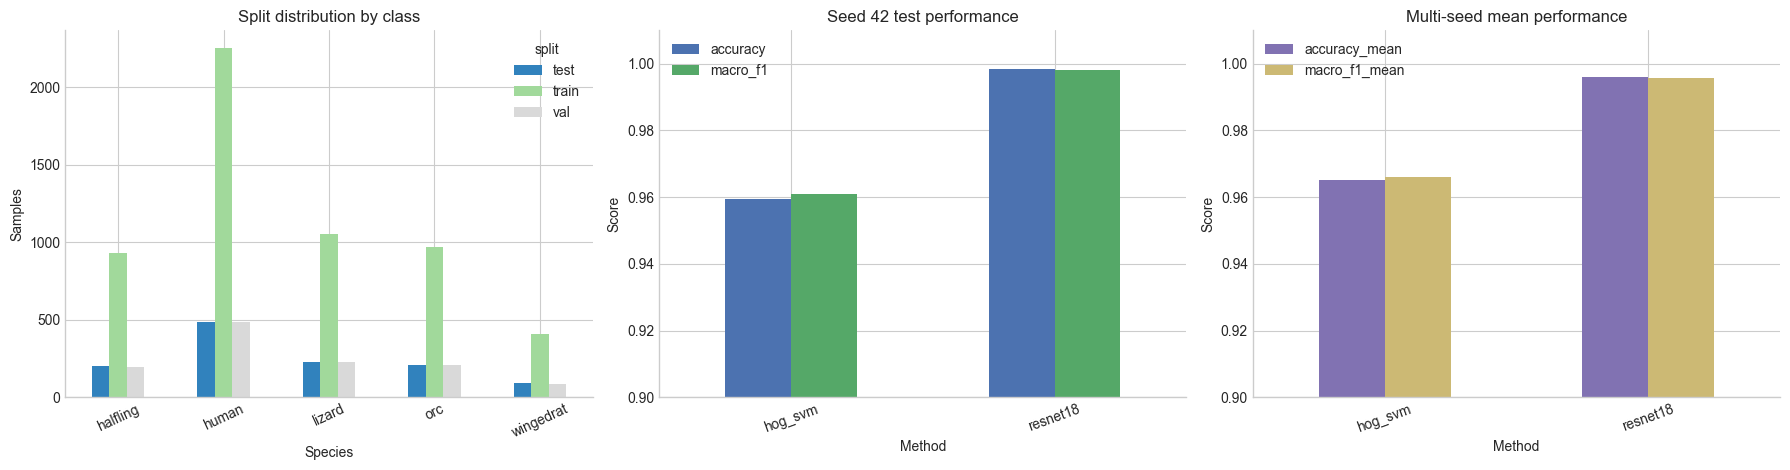

### Seed 42 test comparison

,accuracy,macro_f1,n_samples,method,seed,split
0,95.9%,96.1%,1207,hog_svm,42,test
1,99.8%,99.8%,1207,resnet18,42,test


### Multi-seed stability summary

,method,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std
0,hog_svm,96.5%,0.009,96.6%,0.008
1,resnet18,99.6%,0.005,99.6%,0.005


### HOG tuning sanity check

,stage,warning_count_total,warning_count_mean,accuracy_mean,macro_f1_mean
0,before,2,0.666667,96.4%,96.4%
1,after,2,0.666667,96.5%,96.6%


### Per-class F1 on seed 42

method,class,HOG + SVM F1,ResNet18 F1
0,halfling,93.7%,100.0%
1,human,96.4%,100.0%
2,lizard,97.4%,99.6%
3,orc,94.1%,99.5%
4,wingedrat,98.9%,100.0%


### Task 1 seed 42 confusion matrices

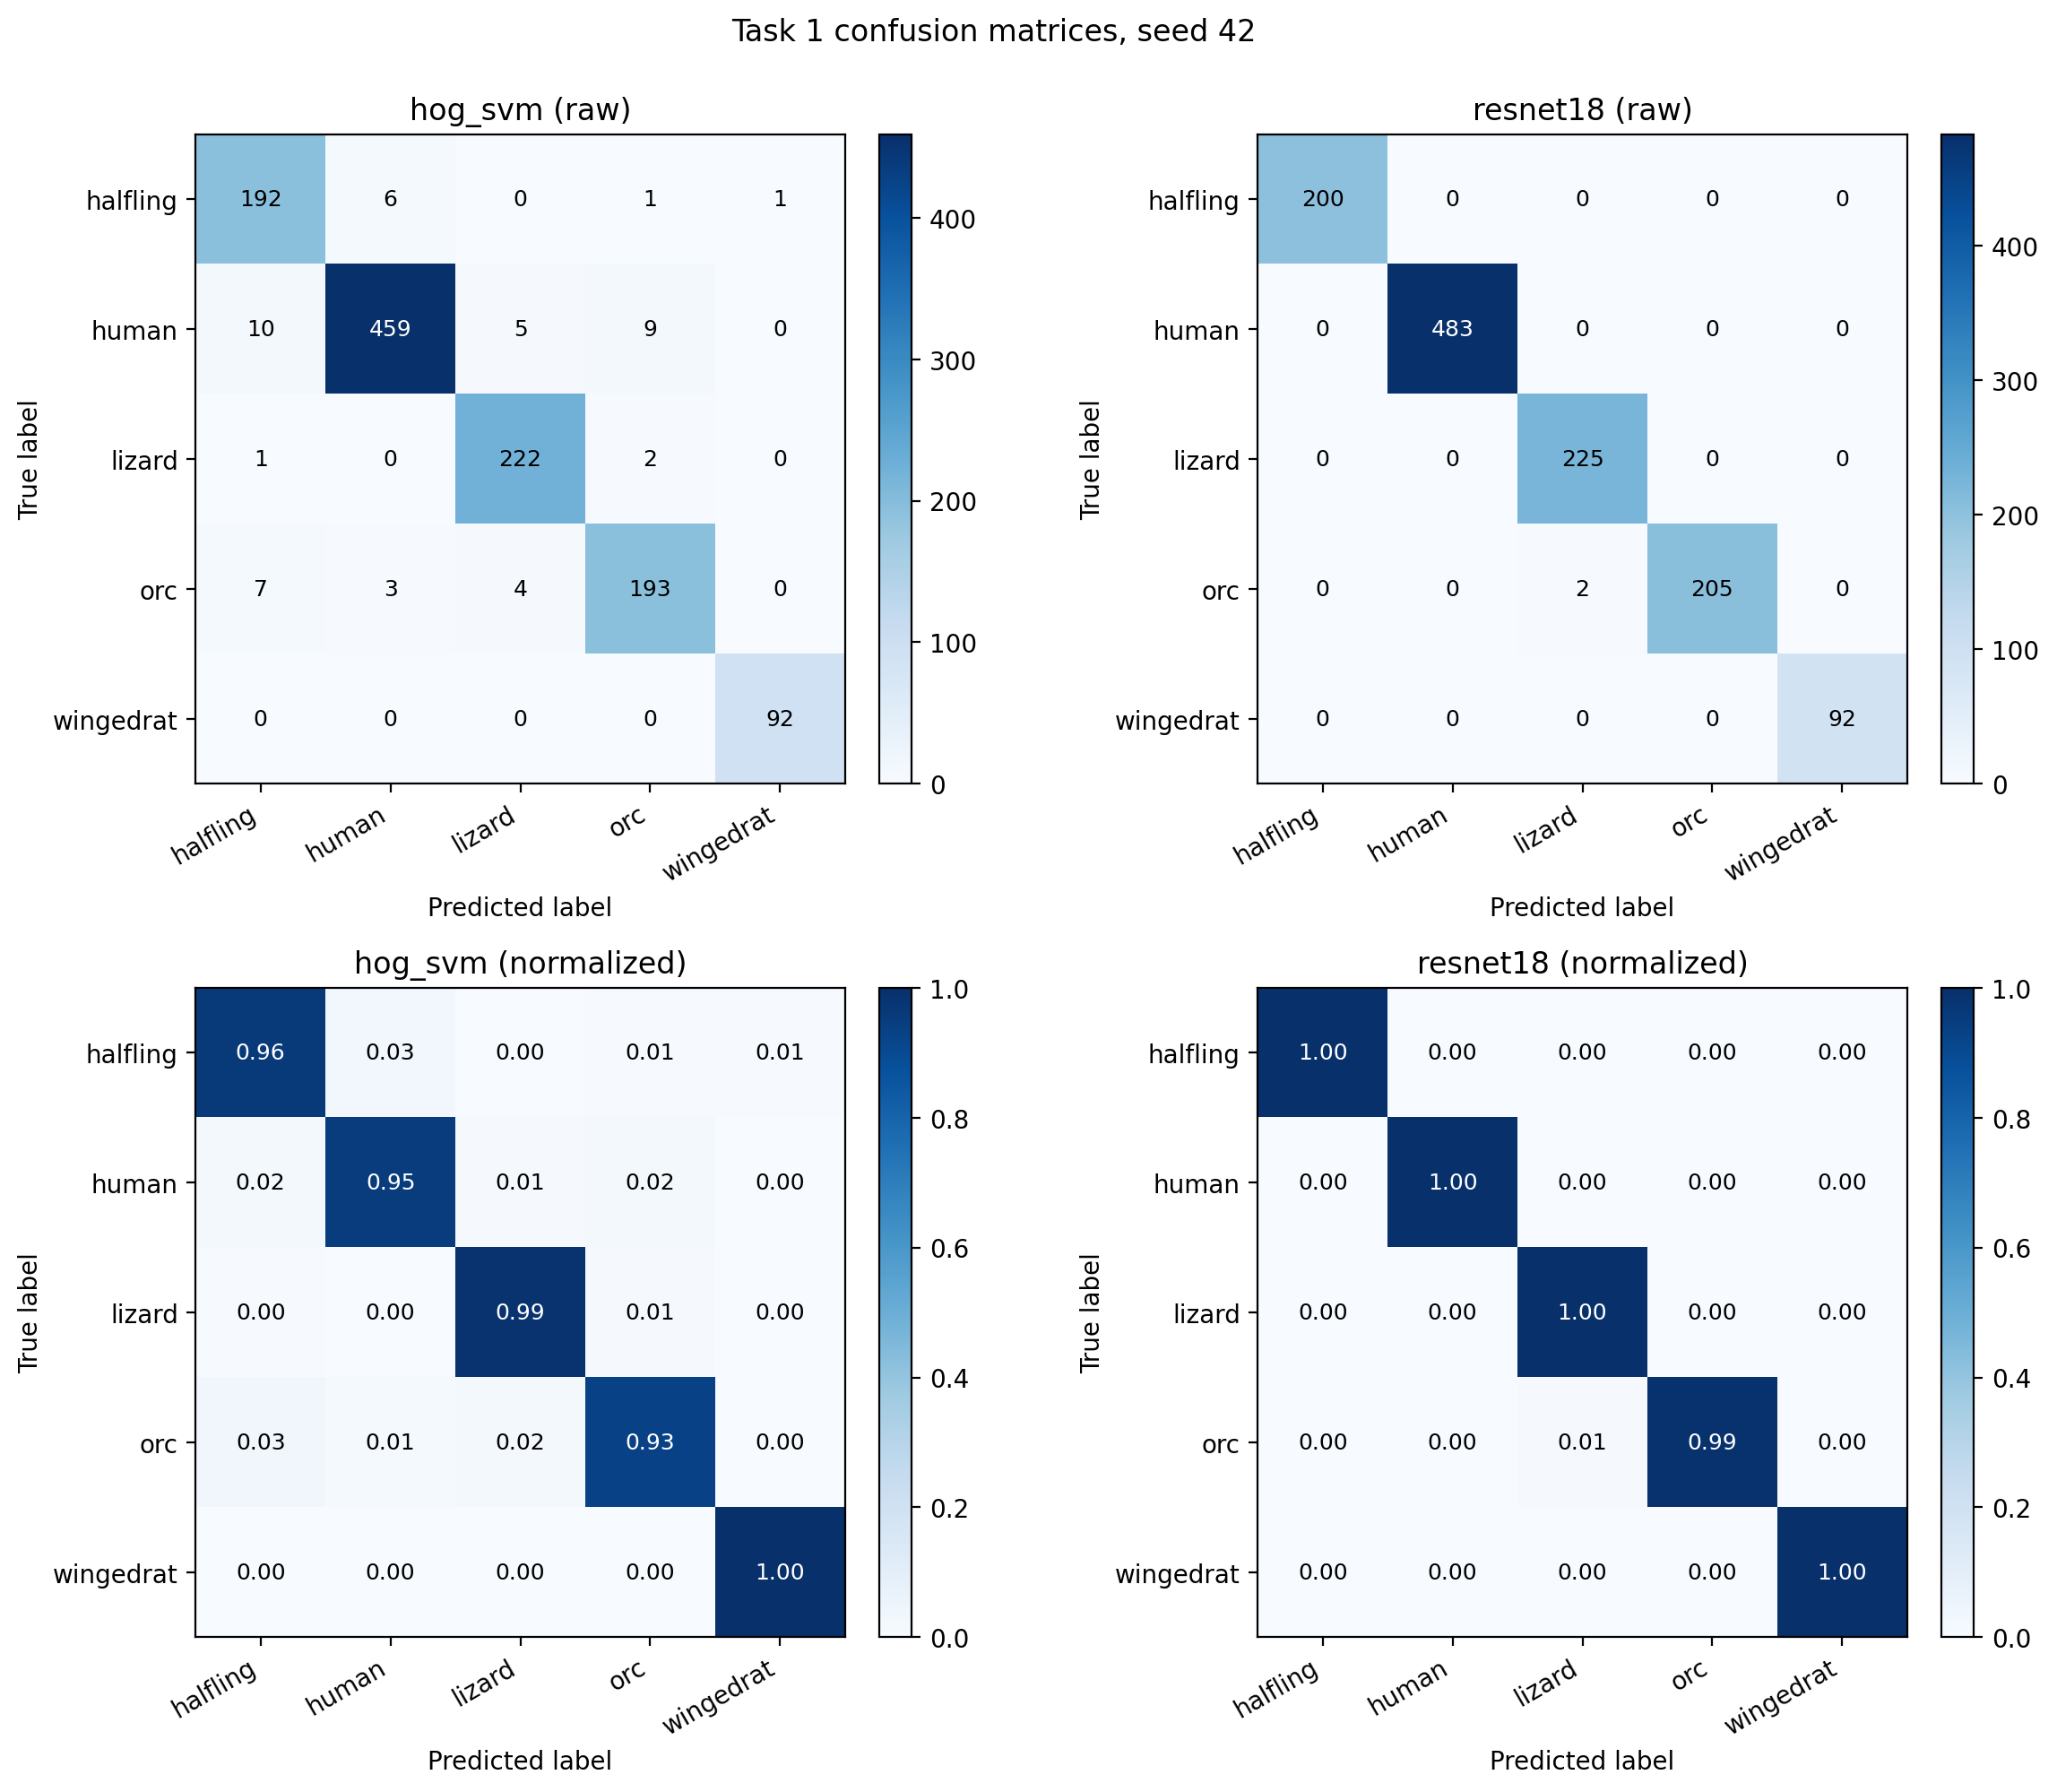

In [3]:
task1_hog_cfg = load_json(TASK1_ROOT / 'configs' / 'hog_svm.json')
task1_resnet_cfg = load_json(TASK1_ROOT / 'configs' / 'resnet18.json')
task1_split_stats = load_csv(TASK1_TABLES / 'split_stats.csv')
task1_seed42 = load_csv(TASK1_TABLES / 'metrics_compare_seed42.csv')
task1_multi = load_csv(TASK1_TABLES / 'metrics_multi_seed_summary.csv')
task1_hog_tuning = load_csv(TASK1_TABLES / 'hog_convergence_before_after_summary.csv')
task1_per_class = load_csv(TASK1_TABLES / 'per_class_compare_seed42.csv')

task1_config_df = pd.DataFrame([
    {
        'Method': 'HOG + Linear SVM',
        'Main design choice': 'Compact grayscale descriptors with balanced linear classification',
        'Key parameters': f"image_size={task1_hog_cfg['image_size']}, C candidates={task1_hog_cfg['c_values']}",
    },
    {
        'Method': 'ResNet18 transfer learning',
        'Main design choice': 'ImageNet pretraining, head warmup, then full fine-tuning',
        'Key parameters': f"epochs={task1_resnet_cfg['epochs']}, warmup={task1_resnet_cfg['warmup_epochs']}, batch={task1_resnet_cfg['batch_size']}",
    },
])
display(Markdown('### Task 1 configuration summary'))
display(task1_config_df)

task1_split_pivot = (
    task1_split_stats.pivot(index='label', columns='split', values='count')
    .fillna(0)
    .astype(int)
)

task1_seed42_display = task1_seed42.copy()
task1_seed42_display['accuracy'] = task1_seed42_display['accuracy'].map(fmt_pct)
task1_seed42_display['macro_f1'] = task1_seed42_display['macro_f1'].map(fmt_pct)

task1_multi_display = task1_multi.copy()
task1_multi_display['accuracy_mean'] = task1_multi_display['accuracy_mean'].map(fmt_pct)
task1_multi_display['accuracy_std'] = task1_multi_display['accuracy_std'].map(fmt_float)
task1_multi_display['macro_f1_mean'] = task1_multi_display['macro_f1_mean'].map(fmt_pct)
task1_multi_display['macro_f1_std'] = task1_multi_display['macro_f1_std'].map(fmt_float)

task1_tuning_display = task1_hog_tuning.copy()
task1_tuning_display['accuracy_mean'] = task1_tuning_display['accuracy_mean'].map(fmt_pct)
task1_tuning_display['macro_f1_mean'] = task1_tuning_display['macro_f1_mean'].map(fmt_pct)

task1_per_class_view = task1_per_class.pivot(index='class', columns='method', values='f1').reset_index()
task1_per_class_view = task1_per_class_view.rename(columns={'hog_svm': 'HOG + SVM F1', 'resnet18': 'ResNet18 F1'})
task1_per_class_view['HOG + SVM F1'] = task1_per_class_view['HOG + SVM F1'].map(fmt_pct)
task1_per_class_view['ResNet18 F1'] = task1_per_class_view['ResNet18 F1'].map(fmt_pct)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
task1_split_pivot.plot(kind='bar', ax=axes[0], colormap='tab20c')
axes[0].set_title('Split distribution by class')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Samples')
axes[0].tick_params(axis='x', rotation=25)

task1_seed42.set_index('method')[['accuracy', 'macro_f1']].plot(kind='bar', ax=axes[1], color=['#4C72B0', '#55A868'])
axes[1].set_title('Seed 42 test performance')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.90, 1.01)
axes[1].tick_params(axis='x', rotation=20)

task1_multi.set_index('method')[['accuracy_mean', 'macro_f1_mean']].plot(kind='bar', ax=axes[2], color=['#8172B2', '#CCB974'])
axes[2].set_title('Multi-seed mean performance')
axes[2].set_xlabel('Method')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0.90, 1.01)
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

display(Markdown('### Seed 42 test comparison'))
display(task1_seed42_display)
display(Markdown('### Multi-seed stability summary'))
display(task1_multi_display)
display(Markdown('### HOG tuning sanity check'))
display(task1_tuning_display)
display(Markdown('### Per-class F1 on seed 42'))
display(task1_per_class_view)

show_image(TASK1_FIGS / 'task1_report_confusion_matrices_seed42.png', 'Task 1 seed 42 confusion matrices', width=1000)

In [4]:
task1_design_df = pd.DataFrame([
    {
        'Aspect': 'Split protocol',
        'Decision': 'Group-aware manifest to reduce leakage across train, validation, and test',
        'Reason': 'The score should reflect recognition ability rather than duplicated near-identical images.',
    },
    {
        'Aspect': 'Baseline method',
        'Decision': 'HOG descriptors plus balanced LinearSVC',
        'Reason': 'Fast, interpretable, and strong enough to test whether handcrafted edges already separate species.',
    },
    {
        'Aspect': 'Deep method',
        'Decision': 'ResNet18 transfer learning with warmup then full fine-tuning',
        'Reason': 'Reuses generic visual features while adapting the classifier head to the dungeon-specific label space.',
    },
])
display(Markdown('### Task 1 design choices'))
display(task1_design_df)

show_snippet(TASK1_ROOT / 'src' / 'train_hog_svm.py', 42, 65, 'Task 1 core logic: HOG feature extraction')
show_snippet(TASK1_ROOT / 'src' / 'train_hog_svm.py', 120, 159, 'Task 1 core logic: validation-driven LinearSVC selection')
show_snippet(TASK1_ROOT / 'src' / 'train_resnet18.py', 260, 333, 'Task 1 core logic: weighted ResNet18 fine-tuning loop')

### Task 1 design choices

,Aspect,Decision,Reason
0,Split protocol,Group-aware manifest to reduce leakage across ...,The score should reflect recognition ability r...
1,Baseline method,HOG descriptors plus balanced LinearSVC,"Fast, interpretable, and strong enough to test..."
2,Deep method,ResNet18 transfer learning with warmup then fu...,Reuses generic visual features while adapting ...


### Task 1 core logic: HOG feature extraction

```python
  42: def build_hog_features(paths: List[str], image_size: int) -> np.ndarray:
  43:     feats: List[np.ndarray] = []
  44:     for path in tqdm(paths, desc="HOG features"):
  45:         img = Image.open(path).convert("L").resize((image_size, image_size))
  46:         arr = np.asarray(img, dtype=np.float32) / 255.0
  47:         feature = hog(
  48:             arr,
  49:             orientations=9,
  50:             pixels_per_cell=(8, 8),
  51:             cells_per_block=(2, 2),
  52:             block_norm="L2-Hys",
  53:             feature_vector=True,
  54:         )
  55:         feats.append(feature)
  56:     return np.asarray(feats, dtype=np.float32)
  57: 
  58: 
  59: def evaluate_and_save(
  60:     method_name: str,
  61:     seed: int,
  62:     split_name: str,
  63:     class_names: List[str],
  64:     y_true: List[str],
  65:     y_pred: List[str],
```

### Task 1 core logic: validation-driven LinearSVC selection

```python
 120:     x_train = build_hog_features(train_df["image_path"].tolist(), args.image_size)
 121:     x_val = build_hog_features(val_df["image_path"].tolist(), args.image_size)
 122:     x_test = build_hog_features(test_df["image_path"].tolist(), args.image_size)
 123: 
 124:     y_train = train_df["label"].tolist()
 125:     y_val = val_df["label"].tolist()
 126:     y_test = test_df["label"].tolist()
 127: 
 128:     c_values = [float(item.strip()) for item in args.c_values.split(",") if item.strip()]
 129: 
 130:     best_model: Pipeline | None = None
 131:     best_c = None
 132:     best_val_f1 = -1.0
 133:     svm_dual = args.svm_dual.lower() == "true"
 134: 
 135:     for c_val in c_values:
 136:         model = Pipeline(
 137:             steps=[
 138:                 ("scaler", StandardScaler()),
 139:                 (
 140:                     "svm",
 141:                     LinearSVC(
 142:                         C=c_val,
 143:                         class_weight="balanced",
 144:                         max_iter=args.max_iter,
 145:                         tol=args.svm_tol,
 146:                         dual=svm_dual,
 147:                         random_state=args.seed,
 148:                     ),
 149:                 ),
 150:             ]
 151:         )
 152:         model.fit(x_train, y_train)
 153:         val_pred = model.predict(x_val)
 154:         val_f1 = f1_score(y_val, val_pred, average="macro")
 155:         if val_f1 > best_val_f1:
 156:             best_val_f1 = val_f1
 157:             best_model = model
 158:             best_c = c_val
 159: 
```

### Task 1 core logic: weighted ResNet18 fine-tuning loop

```python
 260:     for param in model.fc.parameters():
 261:         param.requires_grad = True
 262: 
 263:     model = model.to(device)
 264: 
 265:     train_counts = manifest[manifest["split"] == "train"]["label"].value_counts()
 266:     class_weights = []
 267:     for class_name in class_names:
 268:         count = float(train_counts.get(class_name, 1.0))
 269:         if args.class_weighting == "balanced":
 270:             weight = 1.0 / count
 271:         elif args.class_weighting == "sqrt_balanced":
 272:             weight = 1.0 / np.sqrt(count)
 273:         else:
 274:             weight = 1.0
 275:         class_weights.append(weight)
 276: 
 277:     class_weight_tensor = None
 278:     if args.class_weighting != "none":
 279:         class_weight_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
 280:         class_weight_tensor = class_weight_tensor / class_weight_tensor.mean()
 281: 
 282:     criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
 283:     optimizer = torch.optim.Adam(
 284:         [p for p in model.parameters() if p.requires_grad],
 285:         lr=args.learning_rate_head,
 286:         weight_decay=args.weight_decay,
 287:     )
 288: 
 289:     best_state = None
 290:     best_val_f1 = -1.0
 291:     best_epoch = -1
 292:     patience_count = 0
 293:     history_rows: List[Dict] = []
 294: 
 295:     start_time = time.time()
 296: 
 297:     for epoch in range(1, args.epochs + 1):
 298:         if epoch == args.warmup_epochs + 1:
 299:             for param in model.parameters():
 300:                 param.requires_grad = True
 301:             optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate_full, weight_decay=args.weight_decay)
 302: 
 303:         model.train()
 304:         running_loss = 0.0
 305:         n_train_items = 0
 306:         for x, y, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{args.epochs}"):
 307:             x = x.to(device, non_blocking=True)
 308:             y = y.to(device, non_blocking=True)
 309: 
 310:             optimizer.zero_grad()
 311:             logits = model(x)
 312:             loss = criterion(logits, y)
 313:             loss.backward()
 314:             optimizer.step()
 315: 
 316:             running_loss += loss.item() * x.size(0)
 317:             n_train_items += x.size(0)
 318: 
 319:         train_loss = running_loss / max(n_train_items, 1)
 320:         val_true, val_pred, _, val_loss = evaluate_model(model, val_loader, idx_to_class, device)
 321:         val_summary, _, _, _ = build_classification_outputs(val_true, val_pred, class_names)
 322: 
 323:         history = {
 324:             "epoch": epoch,
 325:             "train_loss": float(train_loss),
 326:             "val_loss": float(val_loss),
 327:             "val_accuracy": float(val_summary["accuracy"]),
 328:             "val_macro_f1": float(val_summary["macro_f1"]),
 329:         }
 330:         history_rows.append(history)
 331: 
 332:         if val_summary["macro_f1"] > best_val_f1:
 333:             best_val_f1 = float(val_summary["macro_f1"])
```

### From Task 1 to Task 2

Task 1 established that species recognition is not arbitrary: the classes are visually learnable, and the observed errors are structured rather than random. That matters for the rest of the project because it suggests the dungeon entities carry stable semantics worth testing from other views of the data.

Task 2 therefore changes the question rather than repeating it. Instead of asking whether labels can be predicted from images, it asks whether the sensor statistics recover a latent grouping that is compatible with, but not identical to, those species semantics. This is the bridge from supervised recognition to unsupervised representation learning.

## Task 2 - Unsupervised Learning

Where Task 1 asked whether classes are recognisable with labels, Task 2 asks whether the sensor statistics contain a stable latent organisation that can be recovered without labels during fitting.

This section again preserves the original Task 2 narrative in full and then rebuilds the main comparative evidence inside the integrated notebook. That keeps the argument about preprocessing, model selection, embeddings, and reflection intact instead of replacing it with a short summary.

K-Means and GMM are compared under the same preprocessing and the same model-selection rule. This is a fair test because it isolates the difference between a hard-assignment centroid model and a softer density model instead of letting each method use a different search space or a different scoring rule.

In [5]:
render_notebook_markdown(
    TASK2_NOTEBOOK,
    extra_heading_level=1,
    preface=(
        "### Preserved Task 2 Narrative\n\n"
        "The block below reproduces the full written explanation from the original Task 2 report notebook. "
        "The integrated evidence cells that follow then rebuild the main comparison tables, plots, and implementation excerpts."
    ),
)

### Preserved Task 2 Narrative

The block below reproduces the full written explanation from the original Task 2 report notebook. The integrated evidence cells that follow then rebuild the main comparison tables, plots, and implementation excerpts.

## Task 2 – Unsupervised Learning

This notebook is the core of the Task 2 report. The task is to discover latent structure in `dungeon_sensorstats.csv` with no supervision during fitting. The hidden `species` column is kept only for post-hoc interpretation and external validation.

The motivation is exploratory: when labels are missing or deliberately withheld, unsupervised learning helps us inspect whether the sensor measurements form meaningful groups or reveal anomalies. That is useful in the robotics / perception setting because it tells us whether the feature space itself contains structure worth trusting.

### Algorithm Choice and Rationale

`K-Means` is a compact centroid baseline. After standardization, it is a good first test when clusters are expected to be roughly compact and roughly spherical. It is fast, interpretable, and easy to profile through cluster means [1].

`Gaussian Mixture Model (GMM)` is the probabilistic counterpart. It supports soft assignments and covariance structure, so it can model overlap and non-spherical cluster geometry better than K-Means [2].

For visualization, `PCA` gives a quick linear overview of the dominant directions of variance, while `UMAP` often shows local neighborhoods and cluster borders more clearly. Using both is a useful way to avoid over-reading a single projection [3], [4].

### Core Implementation Excerpt

The next cell shows the essential preprocessing and clustering logic. The goal is not to duplicate every helper in `src`, but to make the algorithmic choices visible in the notebook itself.

### Design Choices and Parameter Tuning

The project compares candidates over the shared range `k/components = 2..8` and uses the same selection rule for both methods: Silhouette descending, Davies-Bouldin ascending, and Calinski-Harabasz descending. That keeps the comparison fair.

The notebook also reports two views: `method_best`, where each method picks its own best cluster count, and `fixed_same_k`, where both methods are compared at `k=5` to align with the five known species.

### Evaluation and Comparison

Internal metrics drive the main comparison. Silhouette captures compactness and separation, Davies-Bouldin penalizes overlapping or diffuse clusters, and Calinski-Harabasz rewards good between-cluster versus within-cluster scatter. Because hidden species labels are available, I also report ARI and NMI as post-hoc checks, not as training objectives.

The main pattern is that both methods consistently prefer `k=6` in the method-best view, even though there are five known species. That is not a contradiction. Unsupervised structure does not have to align one-to-one with semantic labels.

### Self-Reflection and Limitations

This workflow is intentionally conservative, but it still has clear limits.

- Unsupervised evaluation is intrinsically harder than supervised evaluation. Internal metrics help, but they do not fully capture semantic usefulness.
- K-Means is sensitive to initialization and to the assumption of roughly spherical clusters.
- GMM is more flexible, but also more expensive and more sensitive to covariance conditioning.
- External labels are only used after fitting, so ARI and NMI should be read as validation aids, not as optimization targets.
- The `bribe` feature is a useful warning sign: it can make clusters look better very quickly, so it belongs in sensitivity analysis rather than the main evidence stream.

### Summary

The main conclusion is that both K-Means and GMM recover a very similar latent structure in the sensor statistics. Under the project selection rule, both methods prefer six clusters. K-Means is slightly better on the core internal scores and faster, while GMM provides soft membership and nearly matches the external alignment with hidden species labels.

So the data really does contain a discoverable structure, but the structure is not perfectly identical to the semantic species names. That is exactly what makes this a good unsupervised learning exercise.

### References

[1] scikit-learn developers. *KMeans* documentation. scikit-learn User Guide / API Reference. https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

[2] scikit-learn developers. *GaussianMixture* documentation. scikit-learn User Guide / API Reference. https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html

[3] scikit-learn developers. *PCA* documentation. scikit-learn User Guide / API Reference. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

[4] Leland McInnes, John Healy, and James Melville. *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction.* arXiv:1802.03426. https://arxiv.org/abs/1802.03426

### Task 2 configuration summary

,Method,Search space,Key parameters
0,K-Means,"[2, 3, 4, 5, 6, 7, 8]","n_init=20, max_iter=500, algorithm=lloyd"
1,Gaussian Mixture Model,"[2, 3, 4, 5, 6, 7, 8]","covariance=full, n_init=10, reg_covar=1e-06"


### Shared preprocessing artifact

,artifact_prefix,n_rows,n_features,include_bribe,preprocessing_version,created_at
0,preprocessed_main,10000,9,False,v1_median_impute_continuous_mode_binary_standa...,2026-04-14T14:24:20


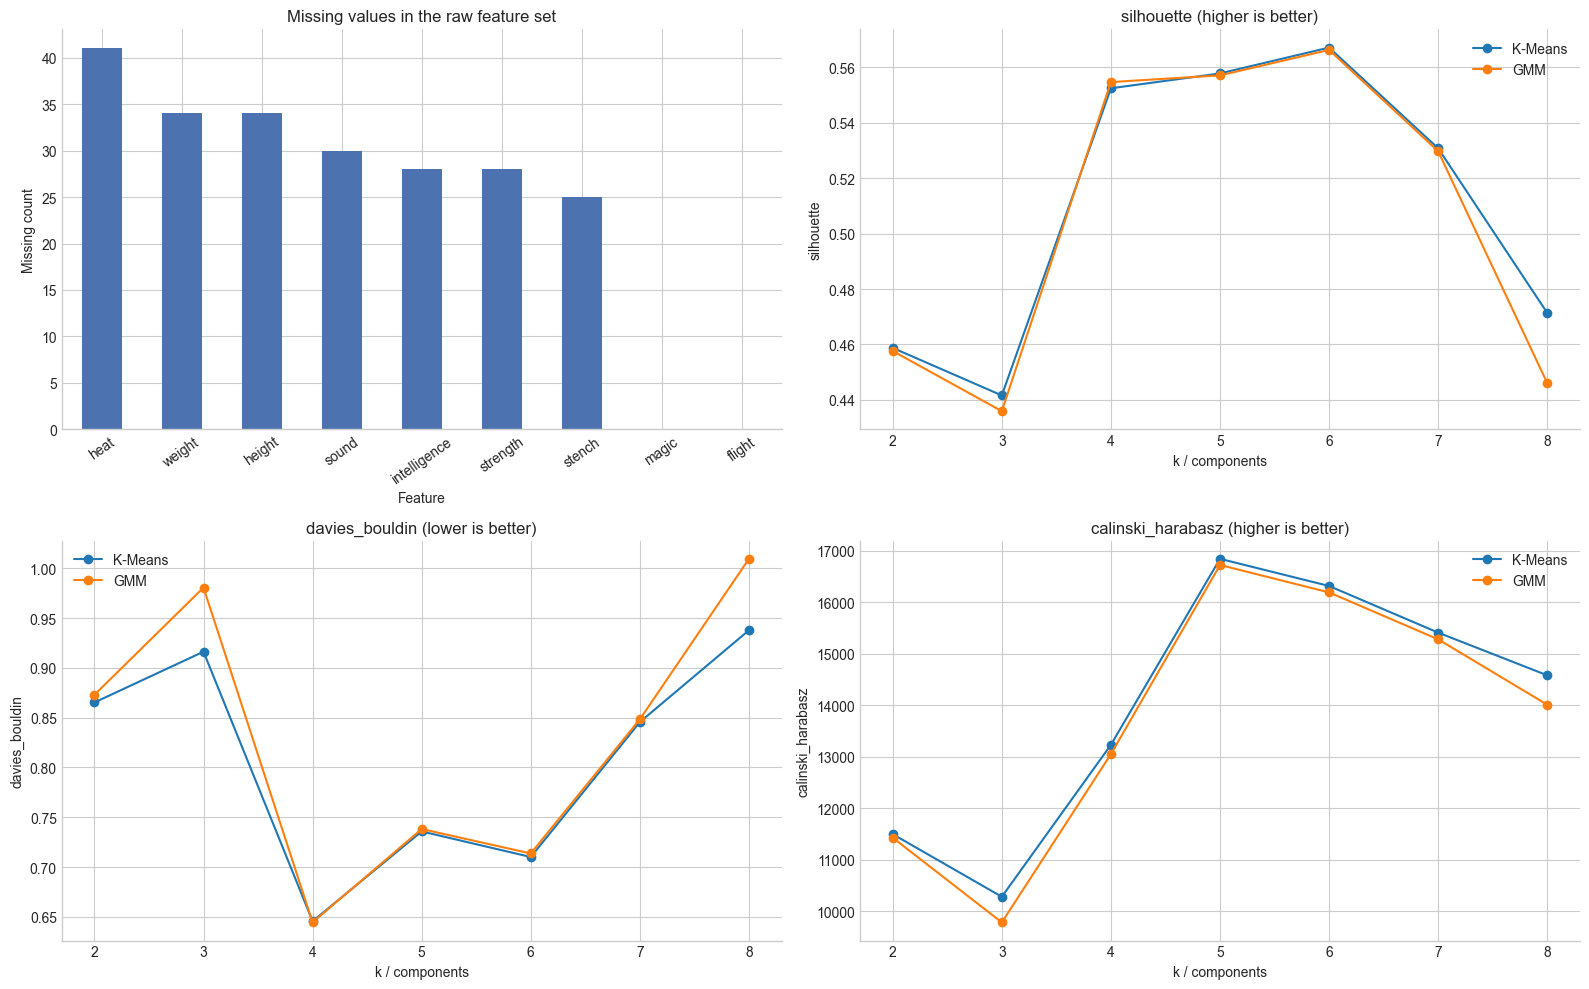

### Seed 42 comparison views

,view,method,seed,selected_clusters,silhouette,davies_bouldin,calinski_harabasz,ari,nmi,fit_seconds
0,fixed_same_k,gmm,42,5,0.557,0.738,16726.066,0.995,0.991,0.147
1,fixed_same_k,kmeans,42,5,0.558,0.736,16845.799,0.985,0.979,0.048
2,method_best,gmm,42,6,0.566,0.714,16193.071,0.947,0.958,0.260
3,method_best,kmeans,42,6,0.567,0.710,16317.844,0.946,0.956,0.048


### Seed 42 selected cluster counts

,method,seed,best_k,fixed_k,best_silhouette,fixed_silhouette
0,kmeans,42,6,5,0.567111,0.557785
1,gmm,42,6,5,0.566270,0.557080


### Multi-seed summary

,view,method,silhouette_mean,silhouette_std,davies_bouldin_mean,davies_bouldin_std,calinski_harabasz_mean,calinski_harabasz_std,fit_seconds_mean,fit_seconds_std
0,fixed_same_k,gmm,0.557,0.000,0.738,0.000,16726.066,0.000,0.132,0.013
1,fixed_same_k,kmeans,0.558,0.000,0.736,0.000,16845.799,0.000,0.047,0.003
2,method_best,gmm,0.566,0.000,0.714,0.000,16193.071,0.000,0.186,0.064
3,method_best,kmeans,0.567,0.000,0.710,0.000,16317.844,0.000,0.049,0.002


### Task 2 selected-model embeddings

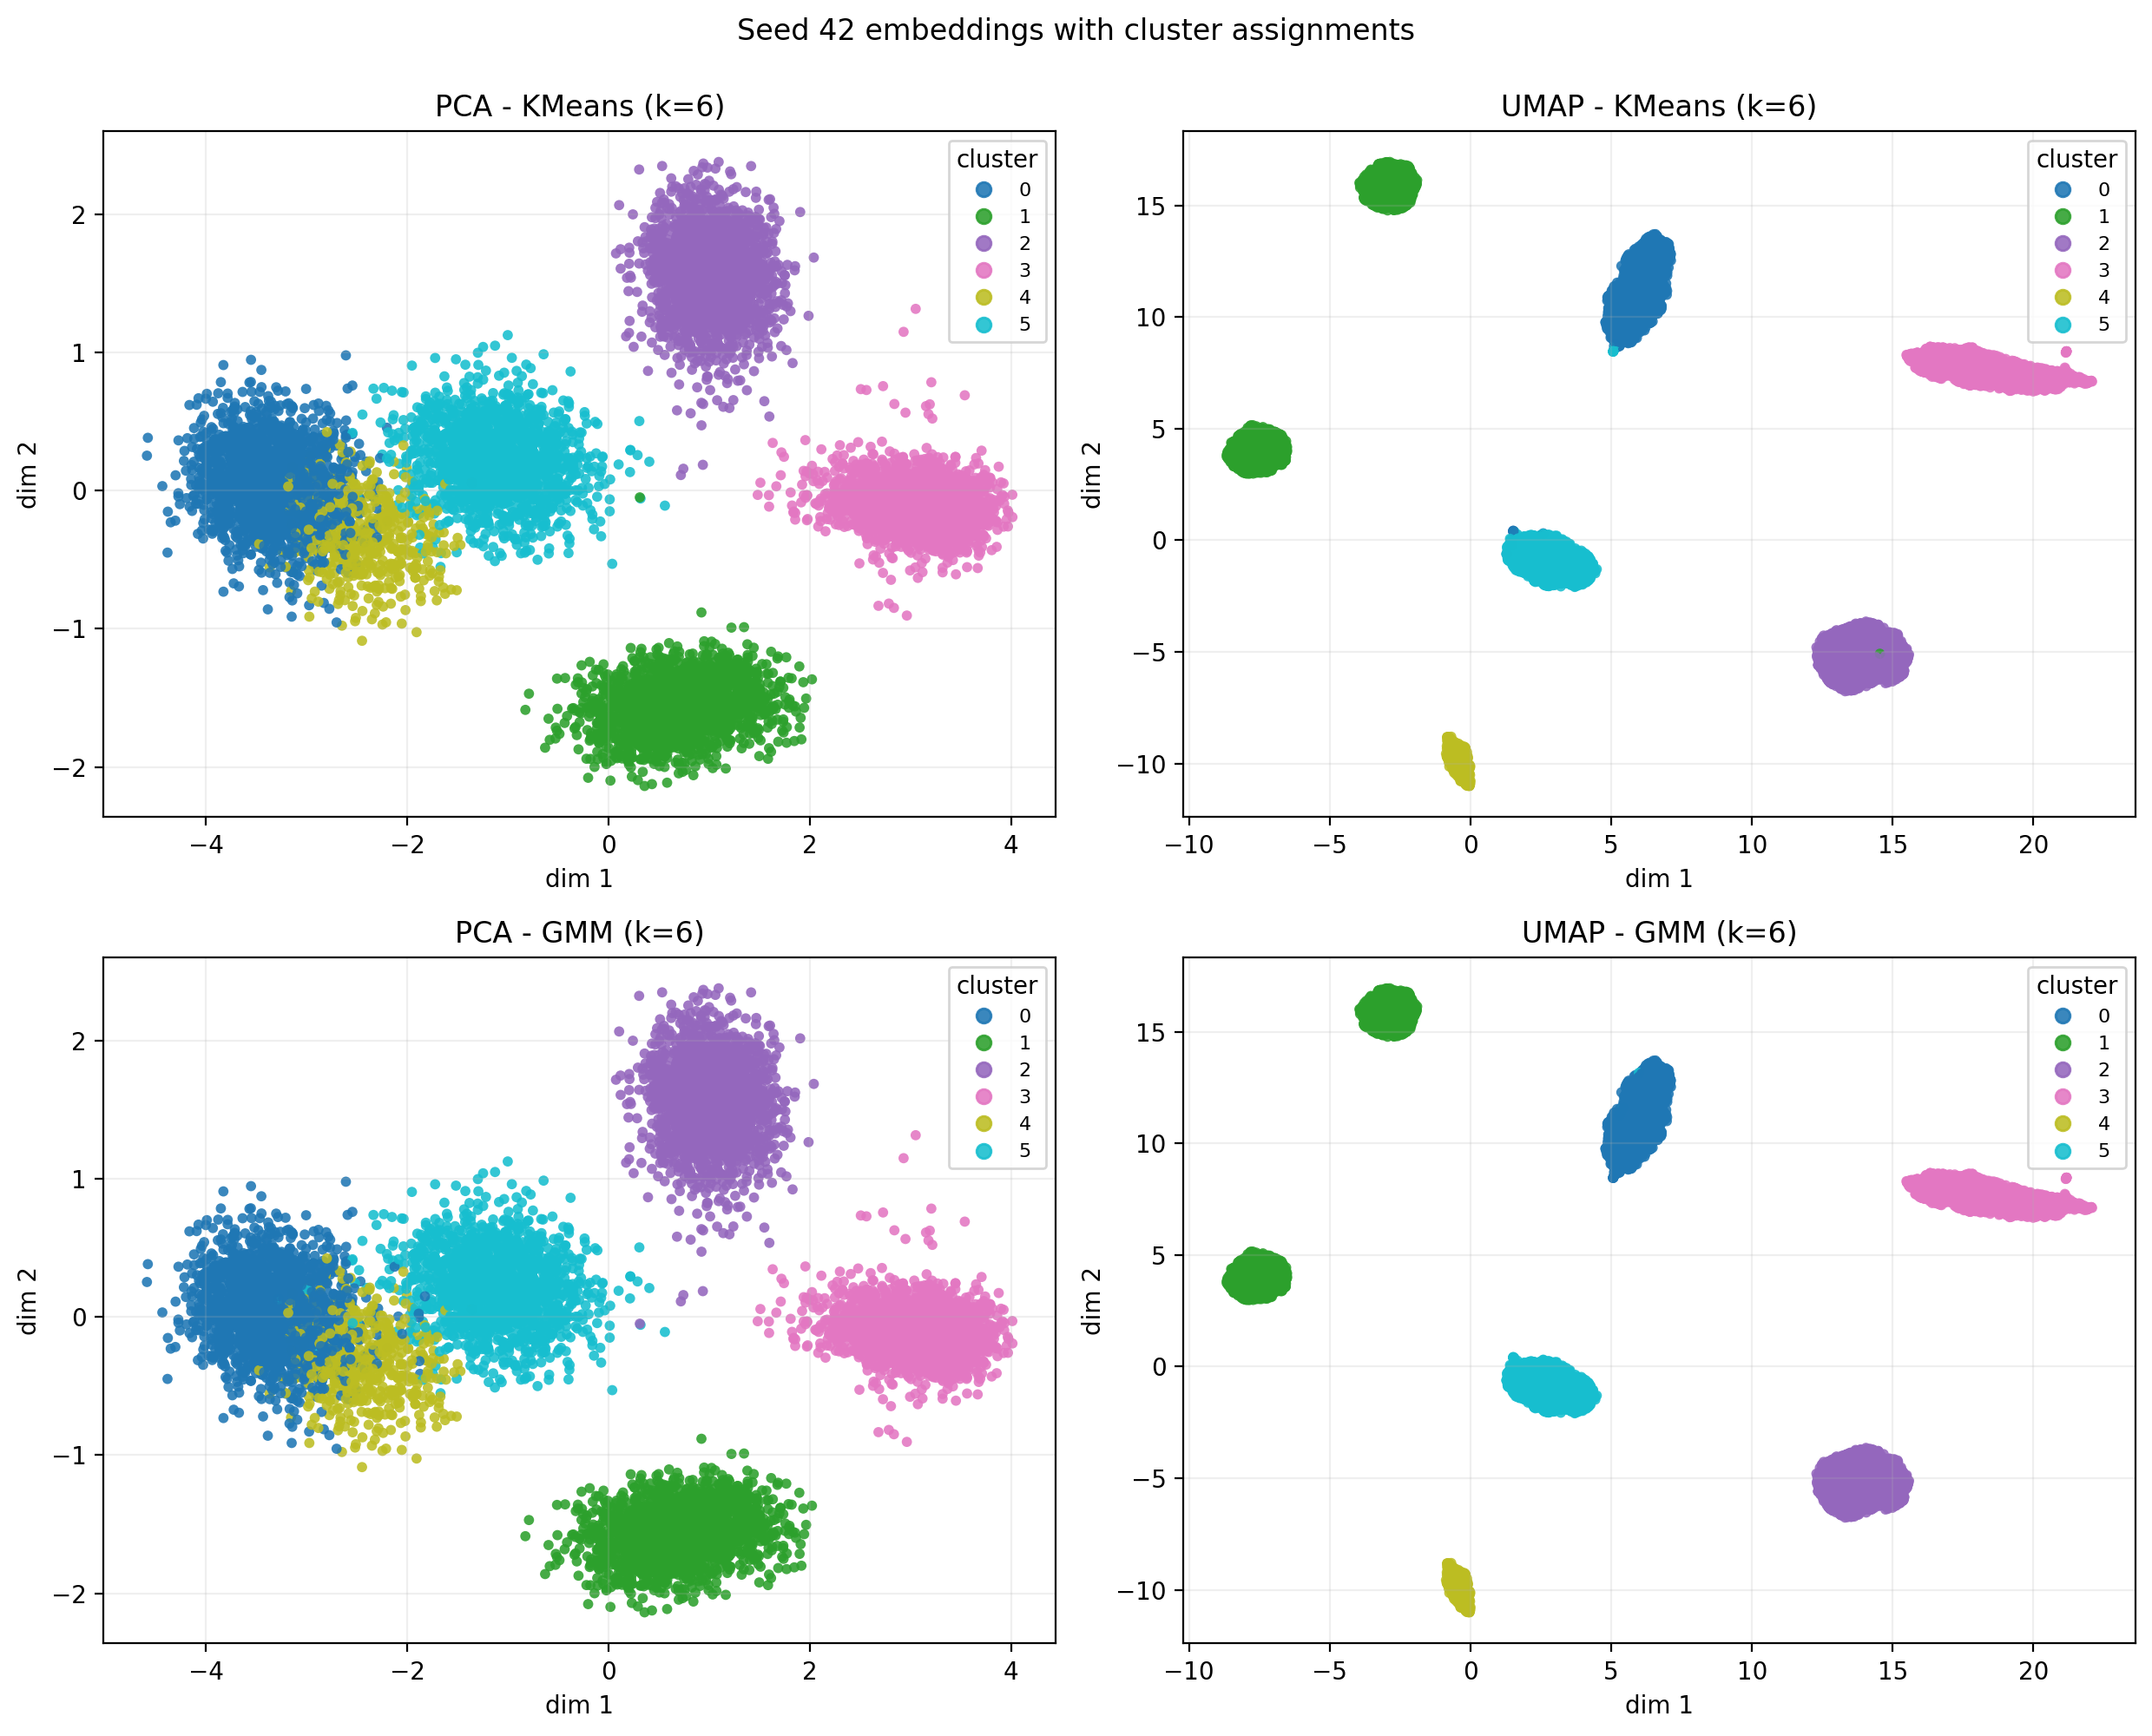

In [6]:
task2_kmeans_cfg = load_json(TASK2_ROOT / 'configs' / 'kmeans.json')
task2_gmm_cfg = load_json(TASK2_ROOT / 'configs' / 'gmm.json')
task2_preproc_summary = load_csv(TASK2_TABLES / 'preprocessed_main_preprocessing_summary.csv')
task2_missing = load_csv(TASK2_TABLES / 'preprocessed_main_missing_summary.csv')
task2_seed42 = load_csv(TASK2_TABLES / 'metrics_compare_seed42.csv')
task2_selection = load_csv(TASK2_TABLES / 'selection_compare_seed42.csv')
task2_multi = load_csv(TASK2_TABLES / 'metrics_multi_seed_summary.csv')
task2_kmeans_metrics = load_csv(TASK2_TABLES / 'metrics_kmeans_seed42.csv')
task2_gmm_metrics = load_csv(TASK2_TABLES / 'metrics_gmm_seed42.csv')

task2_config_df = pd.DataFrame([
    {
        'Method': 'K-Means',
        'Search space': task2_kmeans_cfg['k_range'],
        'Key parameters': f"n_init={task2_kmeans_cfg['n_init']}, max_iter={task2_kmeans_cfg['max_iter']}, algorithm={task2_kmeans_cfg['algorithm']}",
    },
    {
        'Method': 'Gaussian Mixture Model',
        'Search space': task2_gmm_cfg['components_range'],
        'Key parameters': f"covariance={task2_gmm_cfg['covariance_type']}, n_init={task2_gmm_cfg['n_init']}, reg_covar={task2_gmm_cfg['reg_covar']}",
    },
])
display(Markdown('### Task 2 configuration summary'))
display(task2_config_df)
display(Markdown('### Shared preprocessing artifact'))
display(task2_preproc_summary)

task2_seed42_display = task2_seed42.copy()
for column in ['silhouette', 'davies_bouldin', 'calinski_harabasz', 'ari', 'nmi', 'fit_seconds']:
    task2_seed42_display[column] = task2_seed42_display[column].map(fmt_float)

task2_multi_display = task2_multi.copy()
for column in ['silhouette_mean', 'silhouette_std', 'davies_bouldin_mean', 'davies_bouldin_std', 'calinski_harabasz_mean', 'calinski_harabasz_std', 'fit_seconds_mean', 'fit_seconds_std']:
    task2_multi_display[column] = task2_multi_display[column].map(fmt_float)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
task2_missing.sort_values('missing_count', ascending=False).plot(
    kind='bar', x='feature', y='missing_count', ax=axes[0, 0], color='#4C72B0', legend=False
)
axes[0, 0].set_title('Missing values in the raw feature set')
axes[0, 0].set_xlabel('Feature')
axes[0, 0].set_ylabel('Missing count')
axes[0, 0].tick_params(axis='x', rotation=35)

for ax, metric, note in [
    (axes[0, 1], 'silhouette', 'higher is better'),
    (axes[1, 0], 'davies_bouldin', 'lower is better'),
    (axes[1, 1], 'calinski_harabasz', 'higher is better'),
]:
    ax.plot(task2_kmeans_metrics['n_clusters'], task2_kmeans_metrics[metric], marker='o', label='K-Means')
    ax.plot(task2_gmm_metrics['n_clusters'], task2_gmm_metrics[metric], marker='o', label='GMM')
    ax.set_title(f'{metric} ({note})')
    ax.set_xlabel('k / components')
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plt.show()

display(Markdown('### Seed 42 comparison views'))
display(task2_seed42_display)
display(Markdown('### Seed 42 selected cluster counts'))
display(task2_selection)
display(Markdown('### Multi-seed summary'))
display(task2_multi_display)

show_image(TASK2_FIGS / 'task2_report_embeddings_seed42.png', 'Task 2 selected-model embeddings', width=980)

In [7]:
task2_design_df = pd.DataFrame([
    {
        'Aspect': 'Preprocessing',
        'Decision': 'Single shared preprocessing artifact for both clustering methods',
        'Reason': 'Keeps the comparison fair by removing feature-pipeline confounds.',
    },
    {
        'Aspect': 'Model selection',
        'Decision': 'Common ranking rule based on silhouette, Davies-Bouldin, and Calinski-Harabasz',
        'Reason': 'Makes K-Means and GMM directly comparable under the same evidence stream.',
    },
    {
        'Aspect': 'Validation labels',
        'Decision': 'ARI and NMI used only after fitting',
        'Reason': 'Preserves the unsupervised character of the task while still checking semantic usefulness.',
    },
])
display(Markdown('### Task 2 design choices'))
display(task2_design_df)

show_snippet(TASK2_ROOT / 'src' / 'preprocess_data.py', 1, 87, 'Task 2 core logic: shared preprocessing pipeline')
show_snippet(TASK2_ROOT / 'src' / 'train_kmeans.py', 41, 120, 'Task 2 core logic: K-Means candidate scan and export')
show_snippet(TASK2_ROOT / 'src' / 'train_gmm.py', 41, 138, 'Task 2 core logic: GMM candidate scan and soft-assignment export')

### Task 2 design choices

,Aspect,Decision,Reason
0,Preprocessing,Single shared preprocessing artifact for both ...,Keeps the comparison fair by removing feature-...
1,Model selection,"Common ranking rule based on silhouette, Davie...",Makes K-Means and GMM directly comparable unde...
2,Validation labels,ARI and NMI used only after fitting,Preserves the unsupervised character of the ta...


### Task 2 core logic: shared preprocessing pipeline

```python
   1: from __future__ import annotations
   2: 
   3: import argparse
   4: from pathlib import Path
   5: 
   6: import pandas as pd
   7: 
   8: from common import (
   9:     build_preprocessed_data,
  10:     ensure_dirs,
  11:     load_raw_dataset,
  12:     now_stamp,
  13:     resolve_default_data_path,
  14:     resolve_task2_root,
  15:     save_preprocessed_artifacts,
  16:     software_versions,
  17:     write_json,
  18: )
  19: 
  20: 
  21: def parse_args() -> argparse.Namespace:
  22:     parser = argparse.ArgumentParser(description="Task2 preprocessing for fair unsupervised comparison.")
  23:     parser.add_argument(
  24:         "--data-path",
  25:         type=Path,
  26:         default=resolve_default_data_path(),
  27:         help="Path to dungeon_sensorstats.csv",
  28:     )
  29:     parser.add_argument(
  30:         "--outputs-root",
  31:         type=Path,
  32:         default=resolve_task2_root() / "outputs",
  33:         help="Task2 outputs directory",
  34:     )
  35:     parser.add_argument(
  36:         "--artifact-prefix",
  37:         type=str,
  38:         default="preprocessed_main",
  39:         help="Prefix for preprocessing artifacts",
  40:     )
  41:     parser.add_argument(
  42:         "--include-bribe",
  43:         action="store_true",
  44:         help="Include high-risk feature 'bribe' for ablation runs",
  45:     )
  46:     return parser.parse_args()
  47: 
  48: 
  49: def main() -> None:
  50:     args = parse_args()
  51:     outputs_root = args.outputs_root.resolve()
  52:     tables_dir = outputs_root / "tables"
  53:     logs_dir = outputs_root / "logs"
  54:     ensure_dirs(tables_dir, logs_dir)
  55: 
  56:     raw_df = load_raw_dataset(args.data_path.resolve())
  57:     preprocessed = build_preprocessed_data(raw_df, include_bribe=args.include_bribe)
  58:     save_preprocessed_artifacts(preprocessed, tables_dir=tables_dir, artifact_prefix=args.artifact_prefix)
  59: 
  60:     missing_summary = (
  61:         raw_df[preprocessed.feature_columns]
  62:         .isna()
  63:         .sum()
  64:         .rename("missing_count")
  65:         .reset_index()
  66:         .rename(columns={"index": "feature"})
  67:     )
  68:     missing_summary.to_csv(
  69:         tables_dir / f"{args.artifact_prefix}_missing_summary.csv",
  70:         index=False,
  71:     )
  72: 
  73:     summary_df = pd.DataFrame(
  74:         [
  75:             {
  76:                 "artifact_prefix": args.artifact_prefix,
  77:                 "n_rows": int(len(raw_df)),
  78:                 "n_features": int(len(preprocessed.feature_columns)),
  79:                 "include_bribe": bool(args.include_bribe),
  80:                 "preprocessing_version": preprocessed.metadata["preprocessing_version"],
  81:                 "created_at": now_stamp(),
  82:             }
  83:         ]
  84:     )
  85:     summary_df.to_csv(tables_dir / f"{args.artifact_prefix}_preprocessing_summary.csv", index=False)
  86: 
  87:     run_log = {
```

### Task 2 core logic: K-Means candidate scan and export

```python
  41:     parser.add_argument(
  42:         "--config-name",
  43:         type=str,
  44:         default="kmeans.json",
  45:     )
  46:     parser.add_argument(
  47:         "--artifact-prefix",
  48:         type=str,
  49:         default="preprocessed_main",
  50:     )
  51:     return parser.parse_args()
  52: 
  53: 
  54: def main() -> None:
  55:     args = parse_args()
  56:     set_global_seed(args.seed)
  57: 
  58:     outputs_root = args.outputs_root.resolve()
  59:     tables_dir = outputs_root / "tables"
  60:     logs_dir = outputs_root / "logs"
  61:     ensure_dirs(tables_dir, logs_dir)
  62: 
  63:     config = read_json((args.configs_root / args.config_name).resolve())
  64:     data = load_preprocessed_artifacts(tables_dir=tables_dir, artifact_prefix=args.artifact_prefix)
  65: 
  66:     X = data.scaled_features.to_numpy(dtype=float)
  67:     y_true = data.species_labels.to_numpy()
  68:     row_ids = np.arange(len(data.scaled_features), dtype=int)
  69: 
  70:     k_range = [int(v) for v in config["k_range"]]
  71:     n_init = int(config.get("n_init", 10))
  72:     max_iter = int(config.get("max_iter", 300))
  73:     algorithm_raw = str(config.get("algorithm", "lloyd"))
  74:     if algorithm_raw not in {"lloyd", "elkan", "auto", "full"}:
  75:         algorithm_raw = "lloyd"
  76:     algorithm = cast(Literal["lloyd", "elkan", "auto", "full"], algorithm_raw)
  77: 
  78:     rows = []
  79:     for k in k_range:
  80:         start = time.perf_counter()
  81:         model = KMeans(
  82:             n_clusters=k,
  83:             random_state=args.seed,
  84:             n_init=n_init,
  85:             max_iter=max_iter,
  86:             algorithm=algorithm,
  87:         )
  88:         labels = model.fit_predict(X)
  89:         fit_seconds = time.perf_counter() - start
  90: 
  91:         internal = evaluate_internal_metrics(X, labels)
  92:         external = evaluate_optional_external_metrics(y_true, labels)
  93: 
  94:         rows.append(
  95:             {
  96:                 "method": "kmeans",
  97:                 "seed": int(args.seed),
  98:                 "n_clusters": int(k),
  99:                 "silhouette": internal["silhouette"],
 100:                 "davies_bouldin": internal["davies_bouldin"],
 101:                 "calinski_harabasz": internal["calinski_harabasz"],
 102:                 "ari": external["ari"],
 103:                 "nmi": external["nmi"],
 104:                 "fit_seconds": float(fit_seconds),
 105:             }
 106:         )
 107: 
 108:         assign_df = pd.DataFrame(
 109:             {
 110:                 "row_id": row_ids,
 111:                 "species": y_true,
 112:                 "cluster": labels.astype(int),
 113:             }
 114:         )
 115:         assign_df.to_csv(
 116:             tables_dir / f"cluster_assignments_kmeans_seed{args.seed}_k{k}.csv",
 117:             index=False,
 118:         )
 119: 
 120:         center_df = pd.DataFrame(model.cluster_centers_, columns=data.feature_columns)
```

### Task 2 core logic: GMM candidate scan and soft-assignment export

```python
  41:     parser.add_argument(
  42:         "--config-name",
  43:         type=str,
  44:         default="gmm.json",
  45:     )
  46:     parser.add_argument(
  47:         "--artifact-prefix",
  48:         type=str,
  49:         default="preprocessed_main",
  50:     )
  51:     return parser.parse_args()
  52: 
  53: 
  54: def main() -> None:
  55:     args = parse_args()
  56:     set_global_seed(args.seed)
  57: 
  58:     outputs_root = args.outputs_root.resolve()
  59:     tables_dir = outputs_root / "tables"
  60:     logs_dir = outputs_root / "logs"
  61:     ensure_dirs(tables_dir, logs_dir)
  62: 
  63:     config = read_json((args.configs_root / args.config_name).resolve())
  64:     data = load_preprocessed_artifacts(tables_dir=tables_dir, artifact_prefix=args.artifact_prefix)
  65: 
  66:     X = data.scaled_features.to_numpy(dtype=float)
  67:     y_true = data.species_labels.to_numpy()
  68:     row_ids = np.arange(len(data.scaled_features), dtype=int)
  69: 
  70:     components_range = [int(v) for v in config["components_range"]]
  71:     covariance_raw = str(config.get("covariance_type", "full"))
  72:     if covariance_raw not in {"full", "tied", "diag", "spherical"}:
  73:         covariance_raw = "full"
  74:     covariance_type = cast(Literal["full", "tied", "diag", "spherical"], covariance_raw)
  75:     n_init = int(config.get("n_init", 1))
  76:     max_iter = int(config.get("max_iter", 200))
  77:     reg_covar = float(config.get("reg_covar", 1e-6))
  78: 
  79:     rows = []
  80:     for k in components_range:
  81:         start = time.perf_counter()
  82:         model = GaussianMixture(
  83:             n_components=k,
  84:             covariance_type=covariance_type,
  85:             random_state=args.seed,
  86:             n_init=n_init,
  87:             max_iter=max_iter,
  88:             reg_covar=reg_covar,
  89:         )
  90:         labels = model.fit_predict(X)
  91:         probs = model.predict_proba(X)
  92:         max_posterior = probs.max(axis=1)
  93:         fit_seconds = time.perf_counter() - start
  94: 
  95:         internal = evaluate_internal_metrics(X, labels)
  96:         external = evaluate_optional_external_metrics(y_true, labels)
  97: 
  98:         rows.append(
  99:             {
 100:                 "method": "gmm",
 101:                 "seed": int(args.seed),
 102:                 "n_clusters": int(k),
 103:                 "silhouette": internal["silhouette"],
 104:                 "davies_bouldin": internal["davies_bouldin"],
 105:                 "calinski_harabasz": internal["calinski_harabasz"],
 106:                 "ari": external["ari"],
 107:                 "nmi": external["nmi"],
 108:                 "avg_max_posterior": float(np.mean(max_posterior)),
 109:                 "fit_seconds": float(fit_seconds),
 110:             }
 111:         )
 112: 
 113:         assign_df = pd.DataFrame(
 114:             {
 115:                 "row_id": row_ids,
 116:                 "species": y_true,
 117:                 "cluster": labels.astype(int),
 118:                 "max_posterior": max_posterior.astype(float),
 119:             }
 120:         )
 121:         assign_df.to_csv(
 122:             tables_dir / f"cluster_assignments_gmm_seed{args.seed}_k{k}.csv",
 123:             index=False,
 124:         )
 125: 
 126:         means_array = np.asarray(model.means_, dtype=float)
 127:         means_df = pd.DataFrame(means_array, columns=data.feature_columns)
 128:         means_df.insert(0, "cluster", np.arange(k, dtype=int))
 129:         means_df.to_csv(
 130:             tables_dir / f"cluster_means_gmm_seed{args.seed}_k{k}.csv",
 131:             index=False,
 132:         )
 133: 
 134:         covariances = np.asarray(model.covariances_, dtype=float)
 135:         if covariance_type == "full":
 136:             cov_diag = np.stack([np.diag(covariances[idx]) for idx in range(k)], axis=0)
 137:         elif covariance_type == "tied":
 138:             tied_diag = np.diag(covariances)
```

### From Task 2 to Task 3

Task 2 showed that the sensor space contains a stable latent structure, and that this structure can be summarised by cluster assignments rather than only by raw species labels. That result becomes operational in Task 3, where entity-cluster information is injected into the local observation tensor as a compact semantic cue.

So Task 3 does not start from zero. It inherits the project's earlier lessons: useful abstractions can be learned, feature design matters, and evaluation must compare methods under a fixed contract. The reinforcement-learning section therefore turns representational insight into sequential decision-making under uncertainty.

## Task 3 - Reinforcement Learning

Task 3 turns the earlier representational questions into sequential control. HeroBot must navigate and survive under partial observability, so the result depends not only on the optimiser but also on environment construction, observation design, reward shaping, and curriculum scheduling.

As in the earlier sections, the full original Task 3 written narrative is preserved first and the integrated evidence block follows afterwards. This keeps the environment-modification story, design chronology, evaluation commentary, and GIF discussion inside the final report rather than replacing them with a short recap.

The final controlled comparison uses Reward H physics and the Stage 7 curriculum contract. In the project notes, Reward J is only a label for that controlled comparison setting: PPO v4, PPO v5 plus LSTM, and the DQN comparison checkpoint are all evaluated under the same environment assumptions so that the algorithmic differences remain interpretable.

In [8]:
render_notebook_markdown(
    TASK3_NOTEBOOK,
    extra_heading_level=1,
    preface=(
        "### Preserved Task 3 Narrative\n\n"
        "The block below reproduces the full written explanation from the original Task 3 report notebook. "
        "The integrated evidence cells that follow then rebuild the main comparison plots, code excerpts, and rollout visualisation."
    ),
)

### Preserved Task 3 Narrative

The block below reproduces the full written explanation from the original Task 3 report notebook. The integrated evidence cells that follow then rebuild the main comparison plots, code excerpts, and rollout visualisation.

## Task 3 - Reinforcement Learning

### 1. Title and Task Definition

This notebook is the formal Task 3 reinforcement learning report for HeroBot navigation in a customised DungeonMazeWorld maze. The agent must reach the exit while dealing with sparse terminal reward, dense shaping terms, moving enemies, loop-heavy topology, and partial observability induced by ego-centric local sensing and frame stacking.

Reinforcement learning is the appropriate paradigm because the problem is sequential rather than i.i.d.: the quality of an action depends on long-horizon consequences such as whether a short detour avoids a patrol kill-zone, whether a bribable encounter unlocks a later safe route, and whether a local move leads into a dead loop several steps later. A supervised label for the optimal action is not directly available, so the agent must learn a control policy from interaction, return, and delayed credit assignment.

All tables and figures below are generated directly from the Task 3 codebase and experiment artifacts. The notebook also exposes the exact source snippets that implement the environment extensions, PPO pipeline, DQN pipeline, and curriculum schedule.

### 2. Algorithm Selection and Rationale

#### PPO
PPO is the primary optimisation algorithm because it is an on-policy policy-gradient method with a clipped objective that stabilises updates in high-variance environments. That stability matters here: Reward H mixes small per-step shaping with sharp terminal events such as a large goal reward and severe kill-zone penalties, so policy updates need to remain robust under noisy returns. PPO is also a natural fit when the state is only partially observed from a local ego-centric tensor.

#### DQN
DQN is retained as the classical off-policy value-based baseline. It provides a theoretically meaningful counterpoint because replay-buffer bootstrapping, epsilon-greedy exploration, and Q-value regression are exactly the mechanisms expected to become fragile when rewards are sparse, high variance, and delayed. In this project DQN therefore serves both as a baseline and as an empirical test of those theoretical limitations.

#### Why the project emphasis moved toward PPO
The design emphasis gradually shifted toward PPO because the early DQN dynamics under the Reward H curriculum were markedly slower and more unstable than the PPO family, while the computational burden of repeated replay-buffer sampling and CNN backpropagation remained high. After the PPO line had been optimised, the project still produced a frozen DQN comparison artifact at `outputs/checkpoints/dqn_seed42_rewardH_curriculum_stage7J_dqn/best_model.zip`, and that checkpoint is evaluated below as the value-based reference. The interpretation is important: it is a real, runnable DQN model under the same Reward H curriculum contract, but it should be read as an early comparison baseline rather than as a fully converged DQN optimum.

This distinction keeps the report honest while still allowing a meaningful algorithmic comparison: PPO and recurrent PPO show what the project's main optimisation line achieved, and the frozen DQN checkpoint shows how a value-based baseline behaved under the same environment design.

### 3. Environment Modifications

The base MazeDungeon environment was extended to make the navigation task closer to a difficult sequential decision problem instead of a short deterministic path-finding toy. The final controlled comparison in this notebook uses Reward H physics together with the Stage 7 curriculum contract. In the project notes, Reward J is only a naming layer for that controlled comparison; the underlying environment still comes from `configs/env_stage6_rewardH.json`.

> The complete frozen and post-freeze rule set is recorded in `TASK3_FINAL_RULES.md`; this section only summarises the key contracts needed for the final report, especially Reward H, the Stage 7 curriculum, and the stealth-specific interaction logic.

The main modifications are: braid-maze loop carving to remove the single-solution bias, Task1 species semantics plus Task2 cluster features, ego-centric local radar observations, explicit loop and wall penalties, dynamic patrol enemies, a weapon-state channel, and frame stacking. Together these changes create partial observability, delayed credit assignment, and richer safety-efficiency trade-offs.

The next cells summarise the frozen contract and the Stage 6/Stage 7 extensions, then print the key implementation snippets from the actual source files.

#### Key Rules Extracted from TASK3_FINAL_RULES.md

The points below condense the most important clauses from `TASK3_FINAL_RULES.md` without reproducing the full document:

- **Grid topology**: the final maze is a `16x16` map whose passable graph is post-processed until it gains exactly **five genuine loops**, so the task is no longer a single-path shortest-route problem.
- **Observation contract**: the frozen reference uses an ego-centric `4x7x7` radar, while Reward H extends it to `5x7x7` and then applies `frame_stack=3`, yielding an effective `15x7x7` input tensor.
- **Channel semantics**: the channels encode terrain/boundary, Task2 entity-cluster ids, A* downhill guidance, breadcrumb memory, and under Reward H an extra weapon-state channel.
- **Entity semantics**: hostile species are `orc`, `lizard`, and `wingedrat`, while `human` and `halfling` remain bribable or neutral; entities are removed on contact to avoid repeated-cost loops.
- **Reward shaping**: the frozen contract combines true-path progress shaping with explicit penalties for wall hits, short stagnation, and dead loops, plus a `+100` success reward at the target.
- **Stealth extension**: Reward H introduces moving patrol kill-zones and a terminal `kill_zone_penalty_h=-50.0`, making the task safety-critical instead of pure path minimisation.
- **Termination logic**: an episode ends either when the target is reached or when the `256`-step horizon is exhausted; under Reward H, kill-zone capture also terminates the episode immediately.
- **Stage 7 comparison rule**: Reward J is only a label for the controlled comparison setting, meaning Reward H physics are held fixed while PPO+LSTM and DQN are compared under the same curriculum schedule.

...

### 6. Evaluation and Comparison

The evaluation emphasises success rate, episode return, steps to goal, dead-loop rate, and wall-collision case rate. Success rate is the primary task objective because reaching the exit is the real goal. Episode return matters because Reward H mixes progress shaping and safety penalties, so it reflects whether the policy is merely surviving or actually solving the task efficiently. Steps to goal quantify route efficiency among successful episodes, while dead-loop and wall-collision rates diagnose failure mode quality rather than treating all failures as equivalent.

Two comparison levels are needed. First, the PPO family should be compared internally to show what the design iterations achieved. Second, the final three-way table should contrast PPO v4, PPO v5 + LSTM, and the DQN comparison artifact under the same Reward H contract. The DQN row is useful because it highlights not only lower success, but also qualitatively different failure behaviour.

#### 6.1 Training Policy Visual Demonstration

The following GIFs show the trained Stage 7 PPO+LSTM policy using the final standard-start slice of the curriculum. Both files come from the same successful rollout and are rendered in two visual styles so that the navigation behaviour is easy to inspect without changing the underlying trajectory.

### 7. Self-Reflection and Limitations

The main limitation is that the value-based branch is represented here by a frozen comparison checkpoint rather than by a converged DQN optimum. That means the three-way table is best interpreted as evidence about relative training dynamics under the fixed Reward H curriculum, not as the final word on the absolute ceiling of value-based methods in this environment. Even so, the DQN row is still informative because the failure pattern is qualitatively distinct: lower success, much lower return, and sharply worse loop and collision diagnostics.

A second limitation is that PPO itself required substantial tuning effort. The final result was not produced by a single algorithm choice alone; it relied on reward redesign, observation redesign, curriculum shaping, and finally recurrent memory. In that sense PPO was effective, but not magically sample efficient.

A third limitation is environmental abstraction. The stealth extensions create a richer sequential decision problem than the baseline maze, but the patrol logic, bribable interactions, and sensing channels are still engineered simplifications. The task is challenging enough for algorithmic comparison, yet still more structured than an unconstrained real-world navigation problem.

Concrete next steps are therefore clear: add stronger value-based baselines such as Double DQN, Dueling DQN, Rainbow, or distributional variants; explore discrete recurrent value methods to address partial observability more directly; investigate distributed data collection to reduce wall-clock cost; and compare against additional policy-gradient or actor-critic families once the controlled Reward H contract is fixed across more seeds.

### 8. Summary

The final outcome is clear. PPO became the strongest family for this task because it combined stable clipped optimisation with an environment design that gradually exposed the long-horizon difficulty of stealth navigation. Stage 6 PPO v4 established that Reward H was learnable, and Stage 7 PPO v5 + LSTM showed that memory materially improved performance under the same controlled contract.

The DQN implementation is complete and the project produced a real comparison checkpoint for it, but its training dynamics were substantially weaker under the same environment assumptions. That behaviour is consistent with the expected difficulty of value bootstrapping in a sparse, high-variance, partially observed maze. Overall, the project demonstrates evidence-based design, careful iteration, and critical comparison rather than treating reinforcement learning as a one-shot optimisation problem.

### 9. References

Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature, 518*(7540), 529-533.

Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). Proximal policy optimization algorithms. *arXiv preprint arXiv:1707.06347*.

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.

Hausknecht, M., & Stone, P. (2015). Deep recurrent Q-learning for partially observable MDPs. *AAAI Fall Symposium on Sequential Decision Making for Intelligent Agents*.

Stable-Baselines3 Contributors. (2026). *Stable-Baselines3 documentation*. https://stable-baselines3.readthedocs.io/

### Task 3 environment contract summary

,Component,Setting,Why it matters
0,Topology,16x16 maze with five braid loops,Removes the trivial single-path bias and creat...
1,Observation,5x7x7 ego-centric radar with frame_stack=3,Creates partial observability and makes memory...
2,Reward H,"path_scale_e=0.05, step_penalty_e=-0.03, kill_...","The agent must trade off progress, safety, and..."
3,Curriculum,"initial level 1, radius step 3, success window...",Makes the long-horizon task learnable before e...


### Task 3 algorithm configuration summary

,Method,Key parameters
0,PPO v5 + LSTM,"lr=0.0003->5e-05, n_steps=2048, batch=256, ent..."
1,DQN comparison checkpoint,"lr=0.0003->5e-05, buffer=100000->50000, eps_fi..."


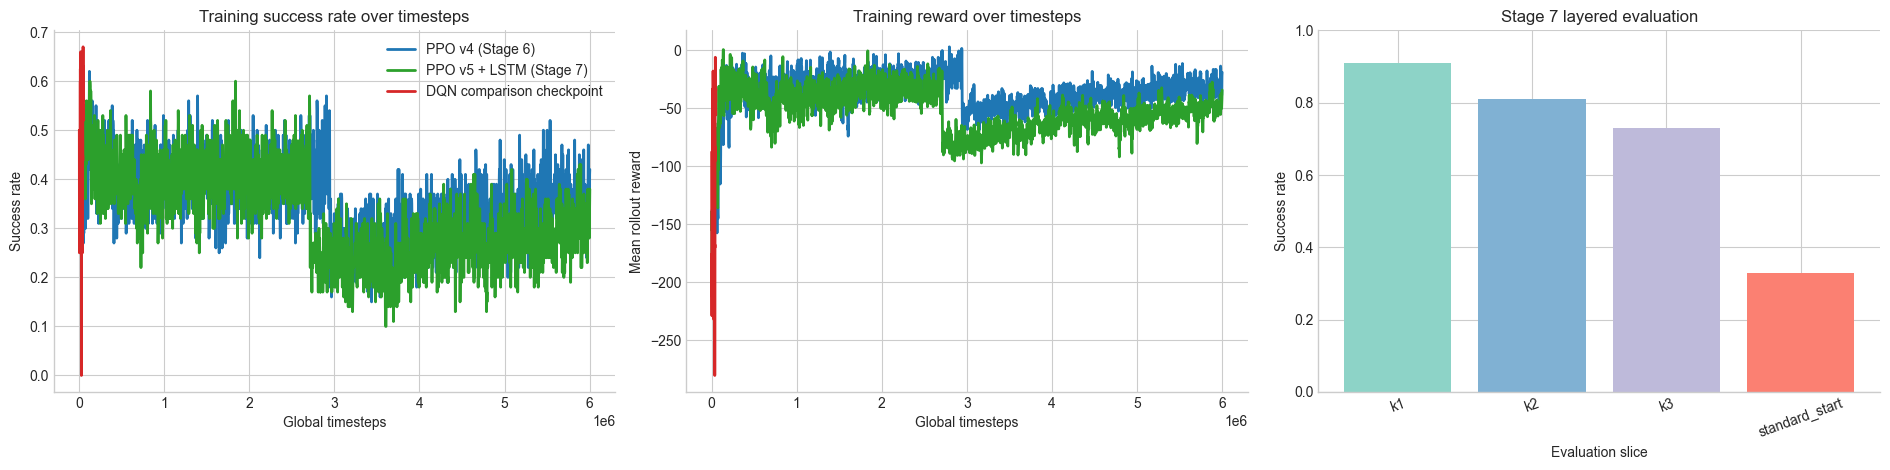

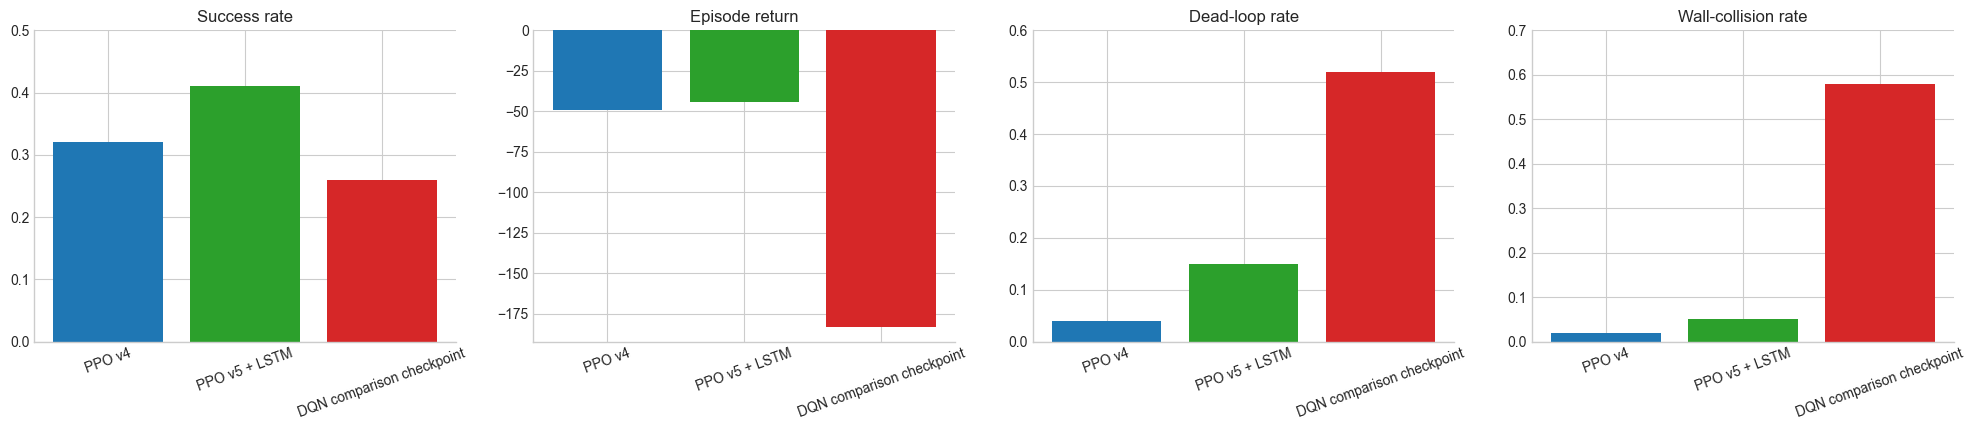

### Final three-way Task 3 comparison

,Method,Family,Success rate,Episode return,Steps to goal,Dead-loop rate,Wall-collision rate,Evaluation episodes
0,PPO v4,Policy gradient,32.0%,-49.308,44.438,4.0%,2.0%,100
1,PPO v5 + LSTM,Recurrent policy gradient,41.0%,-44.343,54.902,15.0%,5.0%,100
2,DQN comparison checkpoint,Value based,26.0%,-183.127,89.538,52.0%,58.0%,50


### Stage 7 layered evaluation for PPO v5 + LSTM

,Evaluation slice,Success rate,Episode return,episode_return_std,Steps mean,Dead-loop rate,Wall-collision rate,n_eval_episodes
0,k1,91.0%,81.665,44.360676,4.670,0.0%,0.0%,100
1,k2,81.0%,57.658,94.314454,10.070,1.0%,1.0%,100
2,k3,73.0%,35.459,120.224226,16.150,3.0%,2.0%,100
3,standard_start,33.0%,-43.844,87.409047,36.260,11.0%,8.0%,100


In [9]:
task3_env_cfg = load_json(TASK3_ROOT / 'configs' / 'env_stage6_rewardH.json')
task3_ppo_cfg = load_json(TASK3_ROOT / 'configs' / 'ppo.json')
task3_dqn_cfg = load_json(TASK3_ROOT / 'configs' / 'dqn_stage7_comparison.json')

task3_runs = {
    'ppo_v4': {
        'label': 'PPO v4 (Stage 6)',
        'metrics': TASK3_TABLES / 'metrics_ppo_seed42_rewardH_curriculum_stage6H_curriculum.csv',
        'progress': TASK3_TABLES / 'progress_ppo_seed42_rewardH_curriculum_stage6H_curriculum.csv',
        'color': '#1f77b4',
    },
    'ppo_v5_lstm': {
        'label': 'PPO v5 + LSTM (Stage 7)',
        'metrics': TASK3_TABLES / 'metrics_ppo_seed42_rewardH_curriculum_stage7J_lstm.csv',
        'progress': TASK3_TABLES / 'progress_ppo_seed42_rewardH_curriculum_stage7J_lstm.csv',
        'color': '#2ca02c',
    },
    'dqn_stage7_comparison': {
        'label': 'DQN comparison checkpoint',
        'metrics': TASK3_TABLES / 'metrics_dqn_seed42_rewardH_curriculum_stage7J_dqn_stage7_comparison_50k.csv',
        'progress': TASK3_TABLES / 'progress_dqn_seed42_rewardH_curriculum_stage7J_dqn_stage7_comparison_50k.csv',
        'color': '#d62728',
    },
}

task3_metrics_rows = {name: load_csv(meta['metrics']).iloc[0] for name, meta in task3_runs.items()}
task3_progress_rows = {name: load_csv(meta['progress']) for name, meta in task3_runs.items()}
task3_plot_rows = {name: prepare_progress_frame(df) for name, df in task3_progress_rows.items()}
task3_layered = load_csv(TASK3_TABLES / 'metrics_layers_ppo_seed42_rewardH_curriculum_stage7J_lstm.csv')

task3_env_df = pd.DataFrame([
    {
        'Component': 'Topology',
        'Setting': '16x16 maze with five braid loops',
        'Why it matters': 'Removes the trivial single-path bias and creates genuine local ambiguity.',
    },
    {
        'Component': 'Observation',
        'Setting': '5x7x7 ego-centric radar with frame_stack=3',
        'Why it matters': 'Creates partial observability and makes memory relevant.',
    },
    {
        'Component': 'Reward H',
        'Setting': f"path_scale_e={task3_env_cfg['path_scale_e']}, step_penalty_e={task3_env_cfg['step_penalty_e']}, kill_zone_penalty_h={task3_env_cfg['kill_zone_penalty_h']}",
        'Why it matters': 'The agent must trade off progress, safety, and loop avoidance.',
    },
    {
        'Component': 'Curriculum',
        'Setting': 'initial level 1, radius step 3, success window 250, mixed standard starts',
        'Why it matters': 'Makes the long-horizon task learnable before exposing the full start distribution.',
    },
])
display(Markdown('### Task 3 environment contract summary'))
display(task3_env_df)

task3_config_df = pd.DataFrame([
    {
        'Method': 'PPO v5 + LSTM',
        'Key parameters': f"lr={task3_ppo_cfg['learning_rate_start']}->{task3_ppo_cfg['learning_rate_end']}, n_steps={task3_ppo_cfg['n_steps']}, batch={task3_ppo_cfg['batch_size']}, ent_coef={task3_ppo_cfg['ent_coef_start']}->{task3_ppo_cfg['ent_coef_end']}",
    },
    {
        'Method': 'DQN comparison checkpoint',
        'Key parameters': f"lr={task3_dqn_cfg['learning_rate_start']}->{task3_dqn_cfg['learning_rate_end']}, buffer={task3_dqn_cfg['buffer_size_start']}->{task3_dqn_cfg['buffer_size_end']}, eps_final={task3_dqn_cfg['exploration_final_eps']}",
    },
])
display(Markdown('### Task 3 algorithm configuration summary'))
display(task3_config_df)

task3_compare = pd.DataFrame([
    {
        'Method': 'PPO v4',
        'Family': 'Policy gradient',
        'Success rate': float(task3_metrics_rows['ppo_v4']['success_rate']),
        'Episode return': float(task3_metrics_rows['ppo_v4']['episode_return_mean']),
        'Steps to goal': float(task3_metrics_rows['ppo_v4']['steps_to_goal_mean']),
        'Dead-loop rate': float(task3_metrics_rows['ppo_v4']['dead_loop_rate']),
        'Wall-collision rate': float(task3_metrics_rows['ppo_v4']['wall_collision_case_rate']),
        'Evaluation episodes': int(task3_metrics_rows['ppo_v4']['n_eval_episodes']),
    },
    {
        'Method': 'PPO v5 + LSTM',
        'Family': 'Recurrent policy gradient',
        'Success rate': float(task3_metrics_rows['ppo_v5_lstm']['success_rate']),
        'Episode return': float(task3_metrics_rows['ppo_v5_lstm']['episode_return_mean']),
        'Steps to goal': float(task3_metrics_rows['ppo_v5_lstm']['steps_to_goal_mean']),
        'Dead-loop rate': float(task3_metrics_rows['ppo_v5_lstm']['dead_loop_rate']),
        'Wall-collision rate': float(task3_metrics_rows['ppo_v5_lstm']['wall_collision_case_rate']),
        'Evaluation episodes': int(task3_metrics_rows['ppo_v5_lstm']['n_eval_episodes']),
    },
    {
        'Method': 'DQN comparison checkpoint',
        'Family': 'Value based',
        'Success rate': float(task3_metrics_rows['dqn_stage7_comparison']['success_rate']),
        'Episode return': float(task3_metrics_rows['dqn_stage7_comparison']['episode_return_mean']),
        'Steps to goal': float(task3_metrics_rows['dqn_stage7_comparison']['steps_to_goal_mean']),
        'Dead-loop rate': float(task3_metrics_rows['dqn_stage7_comparison']['dead_loop_rate']),
        'Wall-collision rate': float(task3_metrics_rows['dqn_stage7_comparison']['wall_collision_case_rate']),
        'Evaluation episodes': int(task3_metrics_rows['dqn_stage7_comparison']['n_eval_episodes']),
    },
])

task3_compare_display = task3_compare.copy()
for column in ['Success rate', 'Dead-loop rate', 'Wall-collision rate']:
    task3_compare_display[column] = task3_compare_display[column].map(fmt_pct)
for column in ['Episode return', 'Steps to goal']:
    task3_compare_display[column] = task3_compare_display[column].map(fmt_float)

task3_layered_display = task3_layered.rename(columns={
    'layer': 'Evaluation slice',
    'success_rate': 'Success rate',
    'episode_return_mean': 'Episode return',
    'steps_mean': 'Steps mean',
    'dead_loop_rate': 'Dead-loop rate',
    'wall_collision_case_rate': 'Wall-collision rate',
}).copy()
for column in ['Success rate', 'Dead-loop rate', 'Wall-collision rate']:
    task3_layered_display[column] = task3_layered_display[column].map(fmt_pct)
for column in ['Episode return', 'Steps mean']:
    task3_layered_display[column] = task3_layered_display[column].map(fmt_float)

fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
for name, meta in task3_runs.items():
    plot_df = task3_plot_rows[name]
    axes[0].plot(plot_df['global_timesteps'], plot_df['rollout/success_rate'], label=meta['label'], color=meta['color'], linewidth=2)
    axes[1].plot(plot_df['global_timesteps'], plot_df['rollout/ep_rew_mean'], label=meta['label'], color=meta['color'], linewidth=2)

axes[0].set_title('Training success rate over timesteps')
axes[0].set_xlabel('Global timesteps')
axes[0].set_ylabel('Success rate')
axes[0].legend()

axes[1].set_title('Training reward over timesteps')
axes[1].set_xlabel('Global timesteps')
axes[1].set_ylabel('Mean rollout reward')

axes[2].bar(task3_layered['layer'], task3_layered['success_rate'], color=['#8dd3c7', '#80b1d3', '#bebada', '#fb8072'])
axes[2].set_title('Stage 7 layered evaluation')
axes[2].set_xlabel('Evaluation slice')
axes[2].set_ylabel('Success rate')
axes[2].set_ylim(0, 1.0)
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(20, 4.4))
for ax, column in zip(axes, ['Success rate', 'Episode return', 'Dead-loop rate', 'Wall-collision rate']):
    ax.bar(task3_compare['Method'], task3_compare[column], color=['#1f77b4', '#2ca02c', '#d62728'])
    ax.set_title(column)
    ax.tick_params(axis='x', rotation=20)

axes[0].set_ylim(0, 0.5)
axes[2].set_ylim(0, 0.6)
axes[3].set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

display(Markdown('### Final three-way Task 3 comparison'))
display(task3_compare_display)
display(Markdown('### Stage 7 layered evaluation for PPO v5 + LSTM'))
display(task3_layered_display)

### Task 3 design choices

,Aspect,Decision,Reason
0,Environment topology,Post-process the maze until it contains five r...,Makes navigation harder than a trivial shortes...
1,Observation design,Use ego-centric local radar with weapon state ...,Creates partial observability and makes tempor...
2,Curriculum strategy,Increase spawn radius gradually and mix standa...,Improves learnability without changing the fin...


### Task 3 core logic: braid-loop topology construction

```python
 427:     def _carve_braid_loops(self, target_loops: int = 5) -> Tuple[int, int]:
 428:         """Open interior walls until the maze gains the requested number of graph cycles."""
 429:         start = (1, 1)
 430:         target = (self.grid_size - 2, self.grid_size - 2)
 431:         desired_loops = max(0, int(target_loops))
 432:         wall_candidates: List[Tuple[int, int]] = []
 433: 
 434:         if desired_loops <= 0:
 435:             return 0, 0
 436: 
 437:         # Only consider non-boundary interior walls to preserve physical borders.
 438:         for x in range(1, self.grid_size - 1):
 439:             for y in range(1, self.grid_size - 1):
 440:                 pos = (x, y)
 441:                 if pos == start or pos == target:
 442:                     continue
 443:                 cell = self.base_env.maze.get_cell_item(x, y)
 444:                 if cell is not None and str(getattr(cell, "type", "")) == "wall":
 445:                     wall_candidates.append(pos)
 446: 
 447:         if not wall_candidates:
 448:             return 0, 0
 449: 
 450:         candidate_order = list(wall_candidates)
 451:         self.rng.shuffle(candidate_order)
 452: 
 453:         opened_walls = 0
 454:         loops_added = 0
 455:         current_cycle_rank = self._maze_cycle_rank(target)
 456: 
 457:         # Pass 1: prefer candidates that add exactly one loop, improving map readability.
 458:         for x, y in candidate_order:
 459:             if loops_added >= desired_loops:
 460:                 break
 461:             wall_obj = self.base_env.maze.get_cell_item(x, y)
 462:             if wall_obj is None or str(getattr(wall_obj, "type", "")) != "wall":
 463:                 continue
 464: 
 465:             self.base_env.maze.add_cell_item(x, y, None)
 466:             new_cycle_rank = self._maze_cycle_rank(target)
 467:             cycle_gain = new_cycle_rank - current_cycle_rank
 468:             if cycle_gain == 1:
 469:                 opened_walls += 1
 470:                 loops_added += 1
 471:                 current_cycle_rank = new_cycle_rank
 472:             else:
 473:                 self.base_env.maze.add_cell_item(x, y, wall_obj)
 474: 
 475:         # Pass 2 fallback: allow multi-loop gains if still below target.
 476:         if loops_added < desired_loops:
 477:             for x, y in candidate_order:
 478:                 if loops_added >= desired_loops:
 479:                     break
 480:                 wall_obj = self.base_env.maze.get_cell_item(x, y)
 481:                 if wall_obj is None or str(getattr(wall_obj, "type", "")) != "wall":
 482:                     continue
 483: 
 484:                 remaining = desired_loops - loops_added
 485:                 self.base_env.maze.add_cell_item(x, y, None)
 486:                 new_cycle_rank = self._maze_cycle_rank(target)
 487:                 cycle_gain = new_cycle_rank - current_cycle_rank
 488:                 if cycle_gain > 0 and cycle_gain <= remaining:
 489:                     opened_walls += 1
 490:                     loops_added += int(cycle_gain)
```

### Task 3 core logic: observation construction and reset pipeline

```python
 663:     def _build_observation(self) -> np.ndarray:
 664:         channels = 5 if self._is_stealth_scheme() else 4
 665:         obs_dtype = np.float32 if self._is_stealth_scheme() else np.uint8
 666:         obs_matrix = np.zeros((channels, 7, 7), dtype=obs_dtype)
 667: 
 668:         target = self._pos_tuple(self.base_env.target_position)
 669:         rx, ry = self._pos_tuple(self.base_env.robot_position)
 670:         robot_t = (rx, ry)
 671: 
 672:         if not self.true_distance_map:
 673:             self.true_distance_map = self._build_true_distance_map(target)
 674:         robot_dist = self.true_distance_map.get(robot_t)
 675: 
 676:         for iy in range(7):
 677:             for ix in range(7):
 678:                 rel_right = ix - 3
 679:                 rel_forward = 3 - iy
 680:                 mx, my = self._ego_offset_to_world(rel_right=rel_right, rel_forward=rel_forward)
 681: 
 682:                 # Channel 0: terrain wall map with out-of-bounds padded as wall.
 683:                 if mx < 0 or my < 0 or mx >= self.grid_size or my >= self.grid_size:
 684:                     obs_matrix[0, iy, ix] = 1
 685:                 else:
 686:                     cell = self.base_env.maze.get_cell_item(mx, my)
 687:                     is_wall = cell is not None and str(getattr(cell, "type", "")) == "wall"
 688:                     obs_matrix[0, iy, ix] = 1 if is_wall else 0
 689: 
 690:                 # Channel 1: entity radar layer encoded as Task2 cluster ID [1..6].
 691:                 ent = self.entity_map.get((mx, my))
 692:                 if ent is not None:
 693:                     obs_matrix[1, iy, ix] = float(self._entity_cluster_id(ent.species) + 1)
 694:                 else:
 695:                     obs_matrix[1, iy, ix] = 0
 696: 
 697:                 # Channel 2: A* downhill guidance mask toward target.
 698:                 dist = self.true_distance_map.get((mx, my))
 699:                 if robot_dist is not None and dist is not None and dist <= robot_dist:
 700:                     obs_matrix[2, iy, ix] = 1
 701:                 else:
 702:                     obs_matrix[2, iy, ix] = 0
 703: 
 704:                 # Channel 3: breadcrumb memory from recent positions.
 705:                 obs_matrix[3, iy, ix] = 1 if (mx, my) in self.position_window else 0
 706: 
 707:                 if channels > 4:
 708:                     obs_matrix[4, iy, ix] = 1.0 if self.has_weapon else 0.0
 709: 
 710:         return obs_matrix.astype(obs_dtype, copy=False)
 711: 
 712:     def reset(self, *, seed: int | None = None, options: dict | None = None):
 713:         if seed is not None:
 714:             self.rng = np.random.default_rng(seed)
 715: 
 716:         self._reset_episode_stats()
 717:         self.potential_scale_multiplier = 1.0
 718:         self.base_env.reset(seed=seed, options=options)
 719:         opened_walls, braid_loops_added = self._carve_braid_loops(target_loops=self.target_braid_loops)
 720:         # Keep front-view features consistent after topology post-processing.
```

### Task 3 core logic: curriculum reset and sampling policy

```python
 126:     def reset(self, *, seed: int | None = None, options: dict | None = None):
 127:         options = options or {}
 128:         forced_level = options.get("curriculum_level")
 129:         freeze_curriculum = bool(options.get("freeze_curriculum", False))
 130:         force_standard_start = bool(options.get("force_standard_start", False))
 131: 
 132:         obs, info = self.env.reset(seed=seed, options=options)
 133: 
 134:         # Force fixed-level curriculum for pretraining stage.
 135:         if forced_level is None and self.train_fixed_level > 0:
 136:             forced_level = int(np.clip(self.train_fixed_level, 1, self.max_level))
 137:             freeze_curriculum = True
 138:             self.fixed_start_mode = False
 139: 
 140:         sampled_standard_start = False
 141:         if forced_level is None and force_standard_start:
 142:             sampled_standard_start = True
 143:         elif (
 144:             forced_level is None
 145:             and self.mixed_sampling_enabled
 146:             and self.train_fixed_level <= 0
 147:             and not self.fixed_start_mode
 148:         ):
 149:             sampled_standard_start = bool(self.env.rng.random() < self.current_standard_start_ratio)
 150: 
 151:         if sampled_standard_start:
 152:             self.last_sampled_standard_start = True
 153:             self.env.potential_scale_multiplier = float(self.standard_potential_multiplier)
 154:             info.update(self._curriculum_info())
 155:             return obs, info
 156: 
 157:         # Switch to standard starting-point mode when level is high enough.
 158:         if self.fixed_start_mode and forced_level is None:
 159:             self.last_sampled_standard_start = True
 160:             self.env.potential_scale_multiplier = float(self.standard_potential_multiplier)
 161:             info.update(self._curriculum_info())
 162:             return obs, info
 163: 
 164:         level_to_use = int(forced_level) if forced_level is not None else int(self.level)
 165:         if level_to_use >= self.max_level and not freeze_curriculum:
 166:             self.fixed_start_mode = True
 167:             self.level = self.max_level
 168:             self.last_sampled_standard_start = True
 169:             self.env.potential_scale_multiplier = float(self.standard_potential_multiplier)
 170:             info.update(self._curriculum_info())
 171:             return obs, info
 172: 
 173:         radius = int(level_to_use * self.radius_step)
 174:         if (
 175:             forced_level is None
 176:             and self.smooth_bridge_stages > 0
 177:             and level_to_use == self.smooth_bridge_from_level
 178:             and self.smooth_bridge_to_level == self.smooth_bridge_from_level + 1
 179:         ):
 180:             radius = self._effective_radius()
 181:         candidates = self._all_spawn_candidates(radius=radius)
 182:         spawn = (1, 1)
 183:         if candidates:
 184:             idx = int(self.env.rng.integers(low=0, high=len(candidates)))
 185:             spawn = candidates[idx]
 186: 
 187:         self._set_spawn(spawn)
 188:         obs = self.env._build_observation()
 189:         self.last_sampled_standard_start = False
 190:         self.env.potential_scale_multiplier = 1.0
 191: 
 192:         info.update(
 193:             {
 194:                 "curriculum_level": float(level_to_use),
 195:                 "curriculum_bridge_stage": float(self.bridge_stage),
 196:                 "curriculum_spawn_x": float(spawn[0]),
 197:                 "curriculum_spawn_y": float(spawn[1]),
 198:                 "curriculum_radius": float(radius),
 199:                 "curriculum_effective_radius": float(radius),
 200:                 "curriculum_recent_success_rate": float(np.mean(self.recent_success)) if self.recent_success else 0.0,
 201:                 "curriculum_fixed_start": float(1.0 if self.fixed_start_mode else 0.0),
 202:             }
 203:         )
 204:         return obs, info
 205: 
 206:     def step(self, action: int):
 207:         obs, reward, terminated, truncated, info = self.env.step(action)
 208:         info = dict(info)
 209:         info.update(self._curriculum_info())
 210:         return obs, reward, terminated, truncated, info
 211: 
 212:     def update_from_episode(self, is_success: float) -> Dict[str, Any]:
 213:         self.episodes_seen += 1
 214:         self.recent_success.append(float(is_success))
 215: 
 216:         recent_mean = float(np.mean(self.recent_success)) if self.recent_success else 0.0
 217:         leveled_up = False
 218:         switched_to_fixed_start = False
```

### Task 3 core logic: shared TinyCNN feature extractor and DQN decay plan

```python
 204: class TinyCNN(BaseFeaturesExtractor):
 205:     """Lightweight CNN features extractor for stacked 7x7 radar observations."""
 206: 
 207:     def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 512) -> None:
 208:         super().__init__(observation_space, features_dim)
 209:         n_input_channels = int(observation_space.shape[0])
 210: 
 211:         self.cnn = nn.Sequential(
 212:             nn.Conv2d(in_channels=n_input_channels, out_channels=32, kernel_size=3, stride=1, padding=1),
 213:             nn.ReLU(),
 214:             nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
 215:             nn.ReLU(),
 216:             nn.Flatten(),
 217:         )
 218: 
 219:         with th.no_grad():
 220:             sample = th.as_tensor(observation_space.sample()[None]).float()
 221:             n_flatten = int(self.cnn(sample).shape[1])
 222: 
 223:         self.linear = nn.Sequential(
 224:             nn.Linear(n_flatten, features_dim),
 225:             nn.ReLU(),
 226:         )
 227: 
 228:     def forward(self, observations: th.Tensor) -> th.Tensor:
 229:         return self.linear(self.cnn(observations.float()))
 230: 
 231: 
 232: def _build_dqn_decay_plan(config: Dict[str, Any], total_timesteps: int) -> List[Dict[str, Any]]:
 233:     phases = int(config.get("decay_phases", 4))
 234:     phases = max(1, phases)
 235: 
 236:     lr_start = float(config.get("learning_rate_start", config.get("learning_rate", 1e-4)))
 237:     lr_end = float(config.get("learning_rate_end", lr_start))
 238: 
 239:     buffer_start = int(config.get("buffer_size_start", config.get("buffer_size", 200_000)))
 240:     buffer_end = int(config.get("buffer_size_end", buffer_start))
 241:     batch_size = int(config.get("batch_size", 256))
 242: 
 243:     steps = [total_timesteps // phases] * phases
 244:     for i in range(total_timesteps % phases):
 245:         steps[i] += 1
 246: 
 247:     plan: List[Dict[str, Any]] = []
 248:     for i in range(phases):
 249:         alpha = float(i / (phases - 1)) if phases > 1 else 0.0
 250:         phase_lr = lr_start + (lr_end - lr_start) * alpha
 251:         phase_buffer = int(round(buffer_start + (buffer_end - buffer_start) * alpha))
 252:         phase_buffer = max(phase_buffer, batch_size)
 253:         plan.append(
 254:             {
 255:                 "phase": i + 1,
 256:                 "timesteps": int(steps[i]),
 257:                 "learning_rate": float(phase_lr),
```

### Task 3 visual rollout: Stage 7 PPO + LSTM standard-start trajectory

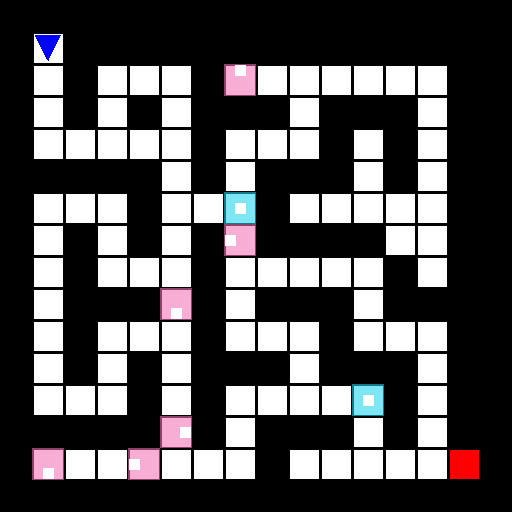

In [10]:
task3_design_df = pd.DataFrame([
    {
        'Aspect': 'Environment topology',
        'Decision': 'Post-process the maze until it contains five real loops',
        'Reason': 'Makes navigation harder than a trivial shortest-path maze.',
    },
    {
        'Aspect': 'Observation design',
        'Decision': 'Use ego-centric local radar with weapon state and frame stacking',
        'Reason': 'Creates partial observability and makes temporal memory relevant.',
    },
    {
        'Aspect': 'Curriculum strategy',
        'Decision': 'Increase spawn radius gradually and mix standard-start episodes into training',
        'Reason': 'Improves learnability without changing the final evaluation contract.',
    },
])
display(Markdown('### Task 3 design choices'))
display(task3_design_df)

show_snippet(TASK3_ROOT / 'src' / 'hero_task3_env.py', 427, 490, 'Task 3 core logic: braid-loop topology construction')
show_snippet(TASK3_ROOT / 'src' / 'hero_task3_env.py', 663, 720, 'Task 3 core logic: observation construction and reset pipeline')
show_snippet(TASK3_ROOT / 'src' / 'curriculum_wrapper.py', 126, 218, 'Task 3 core logic: curriculum reset and sampling policy')
show_snippet(TASK3_ROOT / 'src' / 'train_agents.py', 204, 257, 'Task 3 core logic: shared TinyCNN feature extractor and DQN decay plan')

show_image(TASK3_FIGS / 'stage7_lstm_standard_markers.gif', 'Task 3 visual rollout: Stage 7 PPO + LSTM standard-start trajectory', width=700)

## Overall Conclusion and Future Work

This final notebook intentionally keeps the task-level detail instead of flattening the project into a short executive summary. Read end to end, the three tasks form a single methodological progression. Task 1 establishes that the dungeon species are visually learnable under a controlled split. Task 2 shows that the sensor statistics contain a stable latent structure even when labels are withheld. Task 3 then demonstrates that success in sequential control depends on turning those representational insights into a workable environment contract with informative observations, disciplined rewards, and a curriculum that makes long-horizon learning tractable.

Across all three tasks, the strongest results came from experimental discipline rather than blind model escalation. In Task 1, ResNet18 deserved to win because it was compared against a meaningful handcrafted baseline instead of a strawman. In Task 2, K-Means and GMM were only interpretable because they shared the same preprocessing artifact and the same selection rule. In Task 3, PPO plus LSTM only became convincing after the maze topology, reward schedule, observation tensor, and curriculum policy were iterated into a stable evaluation setting. The project-wide lesson is that fairness, reproducibility, and diagnostic clarity are as important as raw model capacity.

The project also exposes three different kinds of limit. The supervised pipeline could still widen its augmentation and hyperparameter search. The unsupervised study still relies partly on internal validity metrics that only approximate semantic usefulness. The reinforcement-learning comparison still uses a frozen DQN checkpoint rather than a fully converged value-based optimum. Future work should therefore push stronger lightweight vision models for Task 1, richer representation-learning or density methods for Task 2, and a more exhaustive recurrent-versus-value-based comparison for Task 3 under the same fixed environment contract.

## References

1. Dalal, N., & Triggs, B. (2005). Histograms of Oriented Gradients for Human Detection. *CVPR*.
2. He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep Residual Learning for Image Recognition. *CVPR*.
3. scikit-learn developers. *KMeans* documentation.
4. scikit-learn developers. *GaussianMixture* documentation.
5. scikit-learn developers. *PCA* documentation.
6. McInnes, L., Healy, J., & Melville, J. UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction.
7. Mnih, V. et al. (2015). Human-level control through deep reinforcement learning. *Nature*.
8. Schulman, J. et al. (2017). Proximal policy optimization algorithms.
9. Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction*.
10. Stable-Baselines3 Contributors. *Stable-Baselines3 documentation*.